# MISA Extract Transform & Engineer (ETE) Pipeline

This notebook implements a full end-to-end workflow for building a binned‐regression ionospheric background model from Millstone Hill Incoherent Scatter Radar (MISA) data:

1. **Data Extraction & Loading**  
   - Reads raw MISA HDF5 scan groups (timestamps, range, ne/ti/tr, etc.)  
   - Ingests and resamples ancillary geophysical indices (Hp, Ap, Kp, Dst, SME, FISM2) into a unified 30 min timeline

2. **Cleaning & Filtering**  
   - Masks out eclipse/extreme days and bad‐quality radar returns  
   - Removes outliers via relative‐error, standard‐deviation, and percentile‐based filters  
   - Applies NaN masking to bad points

3. **Transformation & Feature Engineering**  
   - Flattens the (time × range) grid to a tabular DataFrame  
   - Computes and reindexes solar-local time (SLT), geomagnetic lat/lon, and time-lagged indices  
   - Generates cyclical features (sin/cos of UT, SLT, DOY), powers/interactions, and log–transformations

4. **Binned Regression Training**  
   - Defines equal‐sized bins in azimuth and altitude  
   - Within each bin, scales inputs, fits a degree-4 polynomial Ridge regression for the target (ne, ti, te)  
   - Stores per-bin models (scaler, transformer, regressor) for fast lookup
   
Use this notebook to reproduce the full model products ionospheric background modeling used in MISA_pySLIME_query.

## 0. Loading Libraries and Defining Functions

In [1]:
# importing libraries
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import pandas as pd
import xarray as xr
import numpy as np
import netCDF4
import h5py
import dask


# dirs
group_name = 'Array_with_kinst=31.0_and_mdtyp=115.0_and_pl=0.002' # MISA instrument data group name
misa_dir = '../ancillary/data_products/MadrigalLib' #data product dir
# geophysical ancillary data dirs
hp_ap_dir = '../ancillary/geophysical_ancillary/Hp30_ap30_complete_series.txt'
kp_f107_dir = '../ancillary/geophysical_ancillary/Kp_ap_Ap_SN_F107_since_1932.txt'
fism2_dir = '../ancillary/geophysical_ancillary/fism2/60s/'
ae_dir = '../ancillary/geophysical_ancillary/supermag_ae.csv'
dst_dir = '../ancillary/geophysical_ancillary/dst2000to2025.txt'

In [2]:
# defining functions
def std_column_filter_mask(a, nbstd):
    """
    Return a boolean mask of outliers in each column of a 2D array.

    Parameters
    ----------
    a : ndarray, shape (n_rows, n_cols)
        Data matrix where rows are observations and columns are variables.
    nbstd : float
        Threshold in standard deviations for identifying outliers.

    Returns
    -------
    mask : ndarray of bool, shape (n_rows, n_cols)
        Boolean array where True indicates an outlier.
    """
    col_means = np.nanmean(a, axis=0)
    col_stds = np.nanstd(a, axis=0)
    upper = col_means + nbstd * col_stds
    lower = col_means - nbstd * col_stds
    return (a > upper) | (a < lower)


def apply_interpolation(data, bad_indices):
    """
    Linearly interpolate over flagged bad entries.

    For each column with bad indices, sets those to NaN, then fills
    them by 1D linear interpolation of the remaining valid data.

    Parameters
    ----------
    data : ndarray, shape (n_rows, n_cols)
        Original data array (will be modified in-place).
    bad_indices : list of (row, col) tuples
        Points to replace via interpolation.

    Returns
    -------
    data : ndarray
        Array with bad points replaced by linear interpolation.
    """
    for col in np.unique([c for _, c in bad_indices]):
        # mask out the bad points
        col_data = data[:, col].copy()
        bad_rows = [r for r, c in bad_indices if c == col]
        col_data[bad_rows] = np.nan
        # only interpolate if there's at least two valid points
        valid = ~np.isnan(col_data)
        if valid.sum() > 1:
            col_data[bad_rows] = np.interp(
                bad_rows, np.where(valid)[0], col_data[valid]
            )
        data[:, col] = col_data
    return data


def apply_nonlinear_interpolation(data, bad_indices, kind='cubic'):
    """
    Replace bad entries via higher-order (cubic, quadratic, etc.) interpolation.

    Parameters
    ----------
    data : ndarray, shape (n_rows, n_cols)
        Original data array.
    bad_indices : list of (row, col) tuples
        Locations to fill.
    kind : str, default 'cubic'
        Interpolation method passed to scipy.interpolate.interp1d.

    Returns
    -------
    data : ndarray
        Array with bad points estimated by nonlinear interpolation.
    """
    for col in np.unique([c for _, c in bad_indices]):
        col_data = data[:, col]
        valid_idx   = np.where(~np.isnan(col_data))[0]
        invalid_idx = np.where(np.isnan(col_data))[0]
        # only proceed if enough valid points exist
        if valid_idx.size > 1:
            interp_fn = interp1d(
                valid_idx, col_data[valid_idx],
                kind=kind, fill_value='extrapolate'
            )
            col_data[invalid_idx] = interp_fn(invalid_idx)
        data[:, col] = col_data
    return data


def load_datasets_with_timestamp_and_range(
    file_path, target_kinst, target_mdtyp, target_pl
):
    """
    Load an HDF5 group matching given instrument/type/parameter, returning an
    xarray.Dataset indexed by real timestamps and range.

    Parameters
    ----------
    file_path : str
        Path to the .hdf5 file.
    target_kinst : float
        Instrument code to match in group key.
    target_mdtyp : float
        Measurement type code.
    target_pl : float
        Physical parameter code.

    Returns
    -------
    ds : xarray.Dataset
        Contains variables at dims ('dates', 'range'), plus coords:
        - 'doy' (day-of-year)
        - 'dates' (datetime64 index).
    """
    with h5py.File(file_path, 'r') as f:
        # locate the matching group by parsing its key
        group_name = None
        for key in f.keys():
            if not key.startswith('Array_with_'): continue
            attrs = dict(p.split('=') for p in key.replace('Array_with_', '').split('_and_'))
            if (float(attrs.get('kinst', -1)) == target_kinst and
                float(attrs.get('mdtyp', -1)) == target_mdtyp and
                float(attrs.get('pl',    -1)) == target_pl):
                group_name = key
                break
        if group_name is None:
            print(f'No matching group for kinst={target_kinst}, mdtyp={target_mdtyp}, pl={target_pl}')
            return np.nan

        grp = f[group_name]
        timestamps = grp['timestamps'][()]
        ranges     = grp['range'][()]

        data_vars = {
            'range':     ('range',     ranges),
            'doy':       None  # will add after coords
        }
        # load each dataset, assigning dims based on shape
        for name, obj in grp.items():
            if name in ('timestamps', 'range'): continue
            arr = obj[()]
            if arr.ndim == 1 and arr.size == timestamps.size:
                data_vars[name] = ('timestamp', arr)
            elif arr.ndim == 2 and arr.shape == (timestamps.size, ranges.size):
                data_vars[name] = (('timestamp','range'), arr)

        # build xarray Dataset and swap to datetime index
        ds = xr.Dataset(data_vars)
        dates = pd.to_datetime(timestamps, unit='s')
        ds = ds.assign_coords(dates=('timestamp', dates)).swap_dims({'timestamp':'dates'})
        # add day-of-year coordinate for feature engineering
        ds['doy'] = ('dates', ds['dates'].dt.dayofyear.values)
    return ds

import os
def concatenate_hdf5_files_in_directory(
    directory_path, target_kinst, target_mdtyp, target_pl
):
    """
    Selects the highest‐revision HDF5 per day for given parameters, then
    concatenates them into one Dataset along the 'dates' dimension.

    Parameters
    ----------
    directory_path : str
        Folder containing .hdf5 files.
    target_kinst, target_mdtyp, target_pl : floats
        Matching criteria for groups within each file.

    Returns
    -------
    concatenated : xarray.Dataset
        Combined time series of all selected files.
    """
    # pick only the latest revision for each base filename
    best = {}
    for fn in os.listdir(directory_path):
        if not fn.endswith('.hdf5'): continue
        parts = fn.split('.')
        base, rev = ('.'.join(parts[:-2]), int(parts[-2])) if parts[-2].isdigit() else (fn, -1)
        if base not in best or rev > best[base][0]:
            best[base] = (rev, fn)

    datasets = []
    for _, fn in sorted(best.values(), key=lambda x: x[1]):
        print(f"Loading {fn}...")
        path = os.path.join(directory_path, fn)
        ds = load_datasets_with_timestamp_and_range(path, target_kinst, target_mdtyp, target_pl)
        if isinstance(ds, xr.Dataset):
            datasets.append(ds)
    if not datasets:
        raise RuntimeError("No valid datasets to concatenate.")
    # merge all along the time axis
    concatenated = xr.concat(datasets, dim='dates')
    return concatenated

def create_geophysical_index_xr(
    hp_ap_dir, kp_f107_dir, dst_dir, supermag_ae_csv, fism2_1min_dir
):
    """
    Reads and merges multiple geophysical indices onto a uniform 30-minute timeline:
      - Hp30 & ap30 from MJD-based ascii files
      - Adjusted F10.7 flux and expanded 3-h Kp values
      - Dst index from hourly ascii
      - SME from SuperMAG AE CSV (1-min → 30-min max)
      - FISM2 irradiance (1-min netCDF → 30-min max)
    Returns:
        xr.Dataset with coords 'dates' (30-min) and data_vars:
          ut, hp30, ap30, f107, kp, dst, sme, fism2
    """
    # 1) LOAD Hp30 & ap30
    hp_ap_df = pd.read_csv(
        hp_ap_dir,
        delim_whitespace=True,
        skiprows=30,   # header offset in ascii file
        header=None,
        names=['YYYY','MM','DD','hh.h','hh._m','days','d_m','Hp30','ap30','D']
    )
    # build datetime index from separate columns
    hp_ap_df['date'] = pd.to_datetime({
        'year':  hp_ap_df['YYYY'],
        'month': hp_ap_df['MM'],
        'day':   hp_ap_df['DD'],
        'hour':  hp_ap_df['hh.h']
    })
    hp_series = hp_ap_df.set_index('date')['Hp30']
    ap_series = hp_ap_df.set_index('date')['ap30']

    # 2) LOAD Kp & adjusted F10.7
    f10_kp_df = pd.read_csv(
        kp_f107_dir,
        delim_whitespace=True,
        skiprows=40,
        header=None,
        names=[
            'YYYY','MM','DD','days','days_m','BSR','dB',
            'Kp1','Kp2','Kp3','Kp4','Kp5','Kp6','Kp7','Kp8',
            'ap1','ap2','ap3','ap4','ap5','ap6','ap7','ap8',
            'Ap','SN','F10.7obs','F10.7adj','D'
        ]
    )
    # replace sentinel -1 with NaN before processing
    f10_kp_df.replace(-1, np.nan, inplace=True)
    # create a daily datetime index for F10.7
    f10_kp_df['date'] = pd.to_datetime({
        'year':  f10_kp_df['YYYY'],
        'month': f10_kp_df['MM'],
        'day':   f10_kp_df['DD']
    })
    f107_series = pd.Series(f10_kp_df['F10.7adj'].values,
                             index=f10_kp_df['date'])

    # expand 3-hourly Kp into 8 snapshots per day
    kp_intervals = pd.to_timedelta([0,3,6,9,12,15,18,21], unit='h')
    expanded = f10_kp_df.loc[f10_kp_df.index.repeat(8)].copy()
    # shift each repeat by the corresponding 3-h offset
    expanded['date'] += np.tile(kp_intervals, len(f10_kp_df))
    # flatten Kp1…Kp8 into a single series
    kp_cols = [f'Kp{i}' for i in range(1,9)]
    expanded['Kp'] = np.concatenate(
        [f10_kp_df[col].values for col in kp_cols]
    )
    kp_series = pd.Series(expanded['Kp'].values, index=expanded['date'])

    # 3) LOAD Dst index
    dst_df = pd.read_csv(dst_dir, delim_whitespace=True, comment='#')
    dst_df['datetime'] = pd.to_datetime(dst_df['DATE'] + ' ' + dst_df['TIME'])
    dst_series = pd.Series(dst_df['DST'].values, index=dst_df['datetime'])

    # 4) LOAD SME (1-min → 30-min max)
    sme_df = pd.read_csv(supermag_ae_csv, parse_dates=['Date_UTC'])
    sme_df.set_index('Date_UTC', inplace=True)
    sme_1m   = sme_df['SME']
    sme_30m  = sme_1m.resample('30T').max()

    # 5) LOAD & PROCESS FISM2 irradiance
    def fix_fism2_dataset(ds):
        # Drop old 'date' dim by converting YYYYDOY -> timestamp
        if 'date' in ds.coords and ds.dims.get('date',0)==1:
            raw = str(ds['date'].item()).strip()
            year, doy = int(raw[:4]), int(raw[4:])
            base = pd.Timestamp(year,1,1) + pd.Timedelta(days=doy-1)
            ds = ds.drop_vars('date')
        else:
            base = None
        # rename & convert 'utc' seconds to real time
        if 'utc' in ds.coords:
            ds = ds.rename(utc='time')
            if base is not None:
                ds['time'] = base + pd.to_timedelta(ds['time'], unit='s')
            ds = ds.assign_coords(time=ds['time'])
        # remove 'jd' index if present
        if 'jd' in ds.dims:    ds = ds.drop_dims('jd')
        if 'jd' in ds.coords:  ds = ds.drop_vars('jd')
        return ds

    files = sorted(Path(fism2_1min_dir).glob("FISM_60sec_*.nc"))
    if not files:
        raise FileNotFoundError(f"No FISM2 files in {fism2_1min_dir}")

    ds_fism2_1m = xr.open_mfdataset(
        files, combine='by_coords', preprocess=fix_fism2_dataset
    )
    # pick the 30.4 nm channel, then resample to 30-min max irradiance
    ds_fism2_1m = ds_fism2_1m.sel(wavelength=30.4, method='nearest')
    fism2_df_1m = ds_fism2_1m['irradiance'].to_dataframe()
    fism2_30m   = fism2_df_1m.resample('30T').max()

    # 6) BUILD THE COMMON 30-MIN TIMELINE
    all_starts = [
        hp_series.index.min(), ap_series.index.min(), f107_series.index.min(),
        kp_series.index.min(), dst_series.index.min(), sme_30m.index.min(),
        fism2_30m.index.min()
    ]
    all_ends   = [
        hp_series.index.max(), ap_series.index.max(), f107_series.index.max(),
        kp_series.index.max(), dst_series.index.max(), sme_30m.index.max(),
        fism2_30m.index.max()
    ]
    dates_full = pd.date_range(min(all_starts), max(all_ends), freq='30T')

    # 7) FORWARD-FILL each series onto the common timeline
    hp30_full  = hp_series.reindex(dates_full, method='ffill')
    ap30_full  = ap_series.reindex(dates_full, method='ffill')
    f107_full  = f107_series.reindex(dates_full, method='ffill')
    kp_full    = kp_series.reindex(dates_full, method='ffill')
    dst_full   = dst_series.reindex(dates_full, method='ffill')
    sme_full   = sme_30m.reindex(dates_full, method='ffill')
    fism2_full = fism2_30m['irradiance'].reindex(dates_full, method='ffill')

    # 8) COMPUTE solar local time (SLT) if needed, here we only output UT
    ut_full = [t.hour + t.minute/60 + t.second/3600 for t in dates_full]

    # 9) ASSEMBLE INTO AN xarray.Dataset
    ds_out = xr.Dataset({
        'ut':   ('dates', ut_full),
        'hp30': ('dates', hp30_full),
        'ap30': ('dates', ap30_full),
        'f107': ('dates', f107_full),
        'kp':   ('dates', kp_full),
        'dst':  ('dates', dst_full),
        'sme':  ('dates', sme_full),
        'fism2':('dates', fism2_full),
    }, coords={'dates': dates_full})

    return ds_out

## 1. Data Extraction & Loading

In [ ]:
### PROCESS MISA DATA ### (if already processed previously, skip this step)
# 1) Load & concatenate all relevant MISA HDF5 files into one xarray.Dataset
MISA_ds = concatenate_hdf5_files_in_directory(
    misa_dir,
    target_kinst=31.0,    # instrument code for MISA
    target_mdtyp=115.0,   # measurement type code for electron density etc.
    target_pl=0.002       # pulse width code
)

# 2) Build boolean masks to remove data from unwanted scan regions:
#    • az_mask: restrict azimuth between densest region
#    • el_mask: only include beams at 6° elevation (both el1 and el2)
#    • gdalt_mask: keep ground‐to‐scatter distance between 0 and 1100 km
az_mask    = (MISA_ds.az1.data < -30) & (MISA_ds.az1.data >= -180)
el_mask    = (MISA_ds.el1.data == 6) & (MISA_ds.el2.data == 6)
gdalt_mask = (MISA_ds.gdalt.data > 0) & (MISA_ds.gdalt.data < 1100)

# 3) Apply each mask to every data variable (skip temporal coords 'doy' & 'slt'):
for mask in (el_mask, gdalt_mask, az_mask):
    for var in MISA_ds.data_vars:
        if var in ('doy', 'slt'):
            continue  # preserve DOY and SLT for later feature alignment
        data = MISA_ds[var]
        # Match mask dimensionality to the variable before masking:
        if data.ndim == mask.ndim:
            # same shape (e.g. 1D → 1D or 2D → 2D)
            MISA_ds[var] = data.where(mask)
        elif data.ndim < mask.ndim:
            # variable is lower‐dimensional (e.g. 1D var masked by 2D mask)
            MISA_ds[var] = data.where(mask.any(axis=1))
        else:
            # variable is higher‐dimensional (e.g. 2D var masked by 1D mask)
            MISA_ds[var] = data.where(mask[:, np.newaxis])

# 4) Sort by timestamp and compute decimal‐hour 'ut'
MISA_ds = MISA_ds.sortby('dates')
MISA_ds['ut'] = (
    MISA_ds['dates'].dt.hour +
    MISA_ds['dates'].dt.minute / 60 +
    MISA_ds['dates'].dt.second / 3600
)
MISA_ds['az_normalized'] = (['dates'],((MISA_ds.az1 + MISA_ds.az2) / 2).values)  # mean beam azimuth (n_times,)

# 5) Load master geophysical indices (Hp, Ap, Kp, Dst, SME, FISM2) on a 30-min grid
master_geo_ds = create_geophysical_index_xr(
    hp_ap_dir, kp_f107_dir, dst_dir, ae_dir, fism2_dir
)

# 6) Align (ffill) geophysical indices to radar timestamps & append to radar data
master_geo_ds_reindexed = master_geo_ds.reindex(
    dates=MISA_ds['dates'], method='ffill'
)
for var in master_geo_ds_reindexed.data_vars:
    MISA_ds[var] = master_geo_ds_reindexed[var]

# 7) Generate time‐lagged indices for feature engineering:
#    - AP at [0,3,5,6,7,9,12,24,48,72] hr prior
for lag in [0, 3, 5, 6, 7, 9, 12, 24, 48, 72]:
    master_geo_ds[f"ap_{lag}hr_prior"] = master_geo_ds['ap30'].interp(
        dates=master_geo_ds['dates'] - pd.Timedelta(f"{lag}H")
    )
#    - 24 hr & 48 hr prior for ap30, dst, sme, fism2
for var in ("ap30", "dst", "sme", "fism2"):
    master_geo_ds[f"{var}_24hr_prior"] = master_geo_ds[var].interp(
        dates=master_geo_ds['dates'] - pd.Timedelta("1D")
    )
    master_geo_ds[f"{var}_48hr_prior"] = master_geo_ds[var].interp(
        dates=master_geo_ds['dates'] - pd.Timedelta("2D")
    )
#    - HP at [0,3,6,9,12,24,48,72] hr prior
for lag in [0, 3, 6, 9, 12, 24, 48, 72]:
    master_geo_ds[f"hp_{lag}hr_prior"] = master_geo_ds['hp30'].interp(
        dates=master_geo_ds['dates'] - pd.Timedelta(f"{lag}H")
    )

# 8) Final align: nearest‐neighbor reindex within 1 hr tolerance and append these lagged vars
master_geo_ds_reindexed = master_geo_ds.reindex(
    dates=MISA_ds['dates'], method='nearest', tolerance=pd.Timedelta("1H")
)
for var in master_geo_ds_reindexed.data_vars:
    MISA_ds[var] = master_geo_ds_reindexed[var]

## PROCESSING AND SAVING ANCILLARY GRID DATASET ##
# grid_ds is used to compute bidirectional interpolators between (az, alt) ↔ (lat, lon)
# it is derived from MISA_ds as such
grid_ds = MISA_ds[['gdalt', 'az_normalized','glon','gdlat']]
grid_ds = grid_ds.where(
    (grid_ds['dates'].dt.date >= np.datetime64('2024-04-01')) &
    (grid_ds['dates'].dt.date <= np.datetime64('2024-04-30')),
    drop=True
)
grid_ds = grid_ds.where(
    (grid_ds['gdalt'] > 0) & (grid_ds['gdalt'] < 510),
    drop=True
)
grid_ds = grid_ds.where(
    (grid_ds['az_normalized'] > -145) & (grid_ds['az_normalized'] < -45),
    drop=True
)

## SAVING DATASETS ##
# save grid_ds to netCDF
grid_ds.to_netcdf(
    '../ancillary/processed_ncs/grid_ds_2.0.8.nc',
    format='NETCDF4', engine='netcdf4', unlimited_dims='dates'
)
# save MISA_ds to netCDF
MISA_ds.to_netcdf(
    '../ancillary/processed_ncs/misa_ds_2.0.8.nc',
    format='NETCDF4', engine='netcdf4', unlimited_dims='dates'
)
# save master_geo_ds to netCDF
master_geo_ds.to_netcdf(
    '../ancillary/processed_ncs/master_geo_ds_2.0.8.nc',
    format='NETCDF4', engine='netcdf4', unlimited_dims='dates'
)

In [3]:
### load preprocessed data (processed as illustrated above)
target_ds = xr.load_dataset('../ancillary/processed_ncs/misa_ds_2.0.8.nc')
master_geo_ds = xr.load_dataset('../ancillary/processed_ncs/master_geo_ds_2.0.6.nc')
# remove duplicates from target_ds
target_ds = target_ds.isel(dates=~pd.Index(target_ds.dates.values).duplicated())

## 2. Cleaning and Filtering

In [4]:
target_variable = 'ne'

MISA_ds = target_ds.copy(deep=True)
# --- 1) LOAD & EXCLUDE UNWANTED DATES ---
# Load eclipse dates to mask out days with total or partial solar eclipse
eclipse_days_df = pd.read_csv('../ancillary/eclipse_days.csv')
eclipse_dates = pd.to_datetime(eclipse_days_df['Date'])

# Load extreme (storm) dates if you wanted to mask them (not used below but available)
extreme_days_df = pd.read_csv('../ancillary/extreme_days.csv')
extreme_dates = pd.to_datetime(extreme_days_df['Storm date'])

# Normalize radar timestamps to just the date (drop time component)
MISA_ds_dates_only = pd.to_datetime(MISA_ds['dates'].values).normalize()

# Mask out any rows whose date is in the eclipse list
MISA_ds = MISA_ds.sel(
    dates=~np.isin(MISA_ds_dates_only, eclipse_dates),
    drop=False
)

# Restrict to days between vernal equinox (Mar 20) and summer solstice (Jun 21)
MISA_ds = MISA_ds.where(
    (
        (MISA_ds['dates'].dt.month == 3) & (MISA_ds['dates'].dt.day >= 20)
    ) | (
        (MISA_ds['dates'].dt.month > 3) & (MISA_ds['dates'].dt.month < 6)
    ) | (
        (MISA_ds['dates'].dt.month == 6) & (MISA_ds['dates'].dt.day <= 21)
    )
)
MISA_ds = MISA_ds.where((MISA_ds['dates'].dt.year <= 2024),drop=True)

# --- 2) DERIVE ADDITIONAL VARIABLES ---
# Compute electron temperature: te = tr * ti
MISA_ds['te']  = MISA_ds['tr'] * MISA_ds['ti']
# Compute delta electron temperature: dte = dtr * dti
MISA_ds['dte'] = MISA_ds['dtr'] * MISA_ds['dti']

# --- 3) COMPUTE RELATIVE ERROR FOR TARGET VARIABLE ---
dvar      = MISA_ds[f'd{target_variable}'].values
dvar_vals  = MISA_ds[target_variable].values
relerr_var = dvar / dvar_vals

# --- 4) DEFINE PERCENTILE‐BASED OUTLIER DETECTOR ---
def filter_data_by_bins_mask(target_array, percentileRange, data=MISA_ds):
    """
    Identify outliers in `target_array` separately within each 100-km gdalt bin.

    For each bin of ground-to-scatter distance:
      1. Extract values in that range (drop NaNs).
      2. Compute the lower and upper percentiles (e.g., [5, 95]).
      3. Flag points below the lower or above the upper cutoff.

    Parameters
    ----------
    target_array : xarray.DataArray
        2D array of the variable to filter (dims: dates × range).
    percentileRange : list or tuple of two floats
        [lower_percentile, upper_percentile], e.g. [5, 95].
    data : xarray.Dataset
        Must contain 'gdalt' for bin definitions.

    Returns
    -------
    mask : np.ndarray (boolean)
        Boolean array of same shape as `target_array`, where True indicates an outlier.
    """
    gdalt_bins = np.arange(0, data['gdalt'].max().data + 100, 100)
    mask = np.full(target_array.shape, False)

    for i in range(len(gdalt_bins) - 1):
        bin_mask = (data['gdalt'] >= gdalt_bins[i]) & (data['gdalt'] < gdalt_bins[i + 1])
        binned = target_array.where(bin_mask, drop=False)

        flat = binned.data.flatten()
        flat = flat[~np.isnan(flat)]
        if flat.size < 2:
            continue

        low, high = np.percentile(flat, percentileRange, method='inverted_cdf')
        mask_pct = (binned < low) | (binned >= high)
        mask |= mask_pct.data

    return mask

# --- 5) COLLECT ALL BAD‐POINT MASKS ---
rel_err_mask = relerr_var > 0.03                                                    # relative instrument error mask
std_bad_mask = std_column_filter_mask(MISA_ds[target_variable].data, nbstd=3.67)    # standard deviation within azimuth mask
percentile_bad_mask = filter_data_by_bins_mask(                                     # percentile mask
    MISA_ds[target_variable], percentileRange=[5, 95]
)
te_bad_mask = MISA_ds['te'].values < 500                                            # non physical values
ti_bad_mask = MISA_ds['ti'].values < 500                                            # non physical values
alt_bad_mask = MISA_ds['gdalt'].values < 150                                          # bad region

# Combine all masks with logical OR
combined_mask = (
    rel_err_mask |
    std_bad_mask |
    percentile_bad_mask |
    te_bad_mask |
    ti_bad_mask |
    alt_bad_mask
)

# --- 6) APPLY NaNs WHERE MASK IS TRUE ---
filtered_var = MISA_ds[target_variable].data.copy()
filtered_var[combined_mask] = np.nan

# --- 7) REPORT FILTERING RESULTS ---
orig_count     = np.count_nonzero(~np.isnan(MISA_ds[target_variable].data))
filtered_count = np.count_nonzero(~np.isnan(filtered_var))
print(f"Original dataset size: {orig_count}")
print(f"Filtered dataset size: {filtered_count}")
print(f"Filtered out {orig_count - filtered_count} bad points ({100 * (orig_count - filtered_count) / orig_count:.2f}%)")

# Overwrite 'ne' in MISA_ds with the cleaned array
MISA_ds[target_variable] = (('dates', 'range'), filtered_var)

/var/folders/46/7rtdvrg92h175wj3d6dq0zjr0000gn/T/ipykernel_27264/1415495545.py:18: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(a, axis=0)
/Users/mateo/Documents/dev/Haystack/MISA_pySLIME/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Original dataset size: 286270
Filtered dataset size: 66015
Filtered out 220255 bad points (76.94%)


## 3. Transformation & Feature Engineering

In [5]:
import numpy as np
import pandas as pd

# 1) Extract core coords & time indices from the cleaned dataset
dates_data    = MISA_ds['dates'].values           # (n_times,)
range_data    = MISA_ds['range'].values           # (n_range,)
normalized_az = MISA_ds['az_normalized'].values   # mean beam azimuth (n_times,)
ut_data       = MISA_ds['ut'].values              # universal time (decimal hours)

# 2) Flatten 2D fields (time × range) to 1D
flat_alt   = MISA_ds['gdalt'].values.flatten()
flat_gdlat = MISA_ds['gdlat'].values.flatten()
flat_glon  = MISA_ds['glon'].values.flatten()
flat_doy   = MISA_ds['doy'].values.flatten()     # day-of-year

# 3) Repeat 1D arrays to align with each time-range pair
n_times = len(dates_data)
n_range = len(range_data)

dates_repeated  = np.repeat(dates_data, n_range)
az_repeated     = np.repeat(normalized_az, n_range)
ut_repeated     = np.repeat(ut_data, n_range)
doy_repeated    = np.repeat(flat_doy, n_range)
range_repeated  = np.tile(range_data, n_times)

# 4) Repeat geophysical indices over range dimension
geophysical_vars = [
    'kp','dst','dst_24hr_prior','dst_48hr_prior',
    'sme','sme_24hr_prior','sme_48hr_prior',
    'fism2','fism2_24hr_prior','fism2_48hr_prior',
    'ap30','ap_3hr_prior','ap_5hr_prior','ap_6hr_prior',
    'ap_7hr_prior','ap_9hr_prior','ap_12hr_prior',
    'hp30','hp_3hr_prior','hp_6hr_prior','hp_9hr_prior','hp_12hr_prior'
]
flat_geophys = {
    var: np.repeat(MISA_ds[var].values, n_range)
    for var in geophysical_vars
}

# 5) Compute SLT from UT + lon/15, adjust DOY when SLT<0
slt = ut_repeated + (flat_glon/15.0)
neg = slt < 0
doy_repeated[neg] -= 1
slt[neg] += 24
slt = slt % 24
doy = doy_repeated % 365

# 5a) flatten the target variable (2D → 1D)
target_data = MISA_ds[target_variable].values.flatten()

# 5b) build harmonics for SLT and DOY
# SLT: 1st and 2nd harmonics (period 24h and 12h)
slt_sin1 = np.sin(2 * np.pi * slt / 24)
slt_sin2 = np.sin(4 * np.pi * slt / 24)
slt_sin3 = np.sin(8 * np.pi * slt / 24)
slt_cos1 = np.cos(2 * np.pi * slt / 24)
slt_cos2 = np.cos(4 * np.pi * slt / 24)
slt_cos3 = np.cos(8 * np.pi * slt / 24)


# DOY: 1st and 2nd harmonics (period 365d and ~182.5d)
doy_sin1 = np.sin(2 * np.pi * doy / 365)
doy_cos1 = np.cos(2 * np.pi * doy / 365)

# 6) Stack everything into a single DataFrame
combined_inputs_df = pd.DataFrame({
    'date':       dates_repeated,
    'doy':        doy,
    'doy_sin1':   doy_sin1,
    'doy_cos1':   doy_cos1,
    'slt':        slt,
    'slt_sin1':   slt_sin1,
    'slt_cos1':   slt_cos1,
    'slt_sin2':   slt_sin2,
    'slt_cos2':   slt_cos2,
    'slt_sin3':   slt_sin3,
    'slt_cos3':   slt_cos3,
    'ut':         ut_repeated,
    'range':      range_repeated,
    'az':         az_repeated,
    'alt':        flat_alt,
    'lat':        flat_gdlat,
    'lon':        flat_glon,
    **flat_geophys,
    target_variable: target_data
})

combined_inputs_df = combined_inputs_df.dropna()

In [6]:
combined_inputs_df

,date,doy,doy_sin1,doy_cos1,slt,slt_sin1,slt_cos1,slt_sin2,slt_cos2,slt_sin3,...,ap_6hr_prior,ap_7hr_prior,ap_9hr_prior,ap_12hr_prior,hp30,hp_3hr_prior,hp_6hr_prior,hp_9hr_prior,hp_12hr_prior,ne
128141,2004-04-15 13:50:04,106.0,0.967938,-0.251190,8.888000,0.727533,-0.686072,-0.998281,-0.058609,0.117017,...,3.0,3.0,5.0,2.0,1.333,2.000,0.667,1.333,0.333,3.246420e+11
128143,2004-04-15 13:50:04,106.0,0.967938,-0.251190,8.888000,0.727533,-0.686072,-0.998281,-0.058609,0.117017,...,3.0,3.0,5.0,2.0,1.333,2.000,0.667,1.333,0.333,3.925150e+11
128145,2004-04-15 13:50:04,106.0,0.967938,-0.251190,8.888000,0.727533,-0.686072,-0.998281,-0.058609,0.117017,...,3.0,3.0,5.0,2.0,1.333,2.000,0.667,1.333,0.333,4.373820e+11
128147,2004-04-15 13:50:04,106.0,0.967938,-0.251190,8.888000,0.727533,-0.686072,-0.998281,-0.058609,0.117017,...,3.0,3.0,5.0,2.0,1.333,2.000,0.667,1.333,0.333,4.961280e+11
128197,2004-04-15 13:50:34,106.0,0.967938,-0.251190,8.852667,0.733848,-0.679313,-0.997026,-0.077067,0.153676,...,3.0,3.0,5.0,2.0,1.333,2.000,0.667,1.333,0.333,3.824220e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8303479,2024-04-22 01:29:19,112.0,0.936881,-0.349647,20.183333,-0.841039,0.540974,-0.909961,-0.414693,0.754710,...,6.0,15.0,15.0,22.0,2.333,2.667,1.667,3.000,3.667,5.452090e+11
8303481,2024-04-22 01:29:19,112.0,0.936881,-0.349647,20.161333,-0.844141,0.536121,-0.905124,-0.425147,0.769622,...,6.0,15.0,15.0,22.0,2.333,2.667,1.667,3.000,3.667,5.983300e+11
8303483,2024-04-22 01:29:19,112.0,0.936881,-0.349647,20.139333,-0.847215,0.531251,-0.900167,-0.435545,0.784127,...,6.0,15.0,15.0,22.0,2.333,2.667,1.667,3.000,3.667,6.430040e+11
8303485,2024-04-22 01:29:19,112.0,0.936881,-0.349647,20.118000,-0.850168,0.526511,-0.895246,-0.445573,0.797794,...,6.0,15.0,15.0,22.0,2.333,2.667,1.667,3.000,3.667,6.470600e+11


In [6]:
# drop elements where SLT < 5
combined_inputs_df = combined_inputs_df[combined_inputs_df['slt'] > 5]

## 3. Binned Regression Training

In [16]:
# combined_inputs_df.to_csv('ti_tokens_training_data_2_0_10.csv', index=False)

In [7]:
# remove test days from training

center_date = pd.to_datetime('2024-04-08')
start_date = center_date - pd.Timedelta(days=3)
end_date = center_date + pd.Timedelta(days=3)

dates_mask = (combined_inputs_df['date'].dt.floor('D') >= start_date) & \
       (combined_inputs_df['date'].dt.floor('D') <= end_date) # elements +- 5 days from eclipse
kp_mask = combined_inputs_df['kp'] < 3 # elements where kp < 3
prox_mask = (np.abs(combined_inputs_df['ut'] - 19.5) < 5) # +- 5 hours from exlipse time

print(f'removing {len(dates_mask)} elements from dataset.')
combined_inputs_df_train = combined_inputs_df.where(~dates_mask).dropna() # drop test days
combined_inputs_df_test = combined_inputs_df.where(dates_mask).dropna() # drop test days

removing 66015 elements from dataset.


In [20]:
combined_inputs_df_test.to_csv('ne_tokens_test_data_2_0_10.csv', index=False)

In [33]:
combined_inputs_df_test[combined_inputs_df_test['date'].dt.date == pd.to_datetime('2024-04-07').date()]

,date,doy,doy_sin1,doy_cos1,slt,slt_sin1,slt_cos1,slt_sin2,slt_cos2,slt_sin3,...,ap_6hr_prior,ap_7hr_prior,ap_9hr_prior,ap_12hr_prior,hp30,hp_3hr_prior,hp_6hr_prior,hp_9hr_prior,hp_12hr_prior,ne
7619991,2024-04-07 00:20:26,97.0,0.995105,-0.098820,19.191333,-0.951755,0.306858,-0.584108,-0.811676,0.948213,...,5.0,6.0,7.0,7.0,2.000,2.000,1.333,2.0,2.000,1.164310e+10
7620233,2024-04-07 00:22:46,97.0,0.995105,-0.098820,18.793333,-0.978509,0.206204,-0.403545,-0.914960,0.738455,...,5.0,6.0,7.0,7.0,2.000,2.000,1.333,2.0,2.000,2.164350e+11
7620235,2024-04-07 00:22:46,97.0,0.995105,-0.098820,18.738000,-0.981393,0.192008,-0.376871,-0.926266,0.698165,...,5.0,6.0,7.0,7.0,2.000,2.000,1.333,2.0,2.000,3.154440e+11
7620237,2024-04-07 00:22:46,97.0,0.995105,-0.098820,18.682667,-0.984072,0.177772,-0.349880,-0.936794,0.655532,...,5.0,6.0,7.0,7.0,2.000,2.000,1.333,2.0,2.000,3.819650e+11
7620239,2024-04-07 00:22:46,97.0,0.995105,-0.098820,18.627333,-0.986544,0.163498,-0.322596,-0.946537,0.610698,...,5.0,6.0,7.0,7.0,2.000,2.000,1.333,2.0,2.000,4.123840e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7678349,2024-04-07 23:39:53,98.0,0.993257,-0.115935,18.190667,-0.998754,0.049896,-0.099667,-0.995021,0.198342,...,15.0,5.0,4.0,9.0,1.667,1.333,3.000,1.0,2.333,5.412960e+11
7678351,2024-04-07 23:39:53,98.0,0.993257,-0.115935,18.164000,-0.999078,0.042922,-0.085765,-0.996315,0.170897,...,15.0,5.0,4.0,9.0,1.667,1.333,3.000,1.0,2.333,6.847950e+11
7678361,2024-04-07 23:39:53,98.0,0.993257,-0.115935,18.037333,-0.999952,0.009774,-0.019546,-0.999809,0.039085,...,15.0,5.0,4.0,9.0,1.667,1.333,3.000,1.0,2.333,6.898630e+11
7678363,2024-04-07 23:39:53,98.0,0.993257,-0.115935,18.013333,-0.999994,0.003491,-0.006981,-0.999976,0.013962,...,15.0,5.0,4.0,9.0,1.667,1.333,3.000,1.0,2.333,6.538150e+11


Points after filtering: 1474


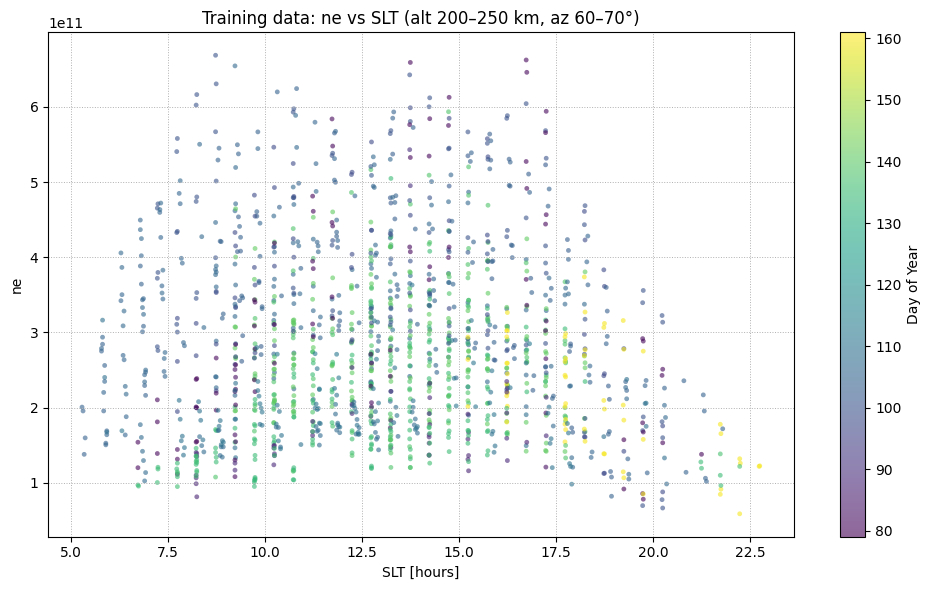

In [134]:
import numpy as np
import matplotlib.pyplot as plt

# Copy to avoid SettingWithCopy warnings
df = combined_inputs_df_train.copy()

# Filter: altitude 200–250 km, azimuth 60–70°
mask = (
    (df['alt'] >= 200) & (df['alt'] <= 250) &
    (df['az']  <= -60) & (df['az']  >= -70)
)
sub = df.loc[mask]

print(f"Points after filtering: {len(sub)}")

# Scatter: SLT vs Ne, color by day-of-year
fig, ax = plt.subplots(figsize=(10, 6))
if 'doy' in sub.columns:
    sc = ax.scatter(sub['slt'], sub['ne'], c=sub['doy'], s=12, alpha=0.6,
                    edgecolors='none', cmap='viridis')
    cbar = plt.colorbar(sc, ax=ax, label='Day of Year')
else:
    ax.scatter(sub['slt'], sub['ne'], s=12, alpha=0.6, edgecolors='none')

ax.set_xlabel('SLT [hours]')
ax.set_ylabel('ne')
ax.set_title('Training data: ne vs SLT (alt 200–250 km, az 60–70°)')
ax.grid(True, ls=':', lw=0.7)


# Optional: uncomment if ne spans many orders of magnitude
# ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# === TRAINING: Binned Polynomial Ridge Regression for each (az, alt) cell ===

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge

# 1) Prepare the DataFrame and restrict to your best-performing az/alt domain
target_df = combined_inputs_df_train.copy(deep=True)

# Define the “core” azimuth & altitude ranges + a small buffer
set_az_domain  = (-140, -40)  # degrees
set_alt_domain = (150,  500)  # km
buffer = 5                    # slack outside the selected domain

# Mask out rows outside the buffered az/alt region
target_df = target_df.where(
    (target_df['az']  > set_az_domain[0] - buffer) &
    (target_df['az']  <= set_az_domain[1] + buffer) &
    (target_df['alt'] > set_alt_domain[0] - buffer) &
    (target_df['alt'] < set_alt_domain[1] + buffer * 5)
)

# 2) Define the bin edges for azimuth & altitude based on grid-search results
target_dAz  = 6.5   # bin width in degrees
target_dAlt = 28    # bin width in km

az_bin_edges  = np.arange(set_az_domain[0], set_az_domain[1] + target_dAz, target_dAz)
alt_bin_edges = np.arange(set_alt_domain[0], set_alt_domain[1] + target_dAlt, target_dAlt)

# Assign each row to an integer bin index
target_df['az_bin']  = pd.cut(target_df['az'],  bins=az_bin_edges,  labels=False, right=False)
target_df['alt_bin'] = pd.cut(target_df['alt'], bins=alt_bin_edges, labels=False, right=False)

# 3) Specify input features and the target variable for regression
geo_physical_features = ['fism2_48hr_prior', 'ap_7hr_prior']
features = [
    'doy',
    'slt',
    'slt_sin1',
    'slt_cos1',
    'slt_sin2',
    'slt_cos2',
    'slt_sin3',
    'slt_cos3',
] + geo_physical_features
target = target_variable

# 4) Prepare dictionaries to collect models and (optionally) debug info
debug_bin_data = {}     # store train/test splits for a specific bin if needed
bin_models     = {}     # final storage for (scaler, poly, model) per bin

# 5) Loop over each (az_bin, alt_bin) cell
for (az_bin, alt_bin), group in target_df.groupby(['az_bin', 'alt_bin']):

    # Skip bins with too few samples to fit a reliable model
    if len(group) <= 5:
        continue

    # Extract feature matrix X and target vector y for this bin
    X_bin = group[features].values
    y_bin = group[target].values

    # Split into train/test (33% for testing)
    X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
        X_bin, y_bin, test_size=0.33, random_state=42
    )

    # Compute the actual physical ranges of this bin (for metadata)
    az_range  = (az_bin_edges[int(az_bin)],   az_bin_edges[int(az_bin) + 1])
    alt_range = (alt_bin_edges[int(alt_bin)], alt_bin_edges[int(alt_bin) + 1])

    # Optional DEBUGGING: capture the splits for one “interesting” bin
    # if (az_range and alt_range near your test_az, test_alt):
    if ((alt_bin == 3.0) & (az_bin == 8.0)):
        debug_bin_data = {
            'X_train': X_train_bin, 'y_train': y_train_bin,
            'X_test':  X_test_bin,  'y_test':  y_test_bin,
            'az_range': az_range, 'alt_range': alt_range,
            'n_samples': len(group)
        }

    # 6) Standardize inputs (zero mean, unit variance) based on training data
    scaler_bin = StandardScaler()
    X_train_scaled = scaler_bin.fit_transform(X_train_bin)

    # 7) Expand features into polynomial terms (up to 4th degree)
    alpha = 1
    if target_variable == 'ne':
        degree = 2
        alpha = 2
    if target_variable == 'te':
        # Manually tuning the model degree and alpha for altitude regimes
        if alt_bin_edges[int(alt_bin)] < 200:
            degree = 1
            alpha = 1
        if 200 <= alt_bin_edges[int(alt_bin)] < 350:
            degree = 2
            alpha = 1
        if 350 <= alt_bin_edges[int(alt_bin)] <= 400:
            degree = 3
            alpha = .66
        if 450 >= alt_bin_edges[int(alt_bin)] > 400:
            degree = 3
            alpha = 1
        if alt_bin_edges[int(alt_bin)] > 500:
            degree = 2

    if target_variable == 'ti':
        if alt_bin_edges[int(alt_bin)] < 250:
            degree = 3
        if 400 > alt_bin_edges[int(alt_bin)] >= 250:
            degree = 3
        if alt_bin_edges[int(alt_bin)] >= 400:
            degree = 2
    #         degree = 8
    #         degree = 12
    #     if alt_bin ==
    # if target_variable == 'ti':
    #     degree = 5
    poly_bin = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_bin.fit_transform(X_train_scaled)

    # 8) Fit a Ridge regression (L2-regularized linear model)
    model_bin = Ridge(alpha=alpha)
    model_bin.fit(X_train_poly, y_train_bin)

    # 9) Save the components for this bin to be used later in prediction
    bin_models[(az_bin, alt_bin)] = {
        'model':   model_bin,
        'scaler':  scaler_bin,
        'poly':    poly_bin,
        'az_range': az_range,
        'alt_range': alt_range,
        'n_samples': len(group)
    }

In [29]:
features

['doy',
 'slt',
 'slt_sin1',
 'slt_cos1',
 'slt_sin2',
 'slt_cos2',
 'slt_sin3',
 'slt_cos3',
 'fism2_48hr_prior',
 'ap_7hr_prior']

In [ ]:
# np.save(f'../model/{target_variable}_model_2_0_10.npy', bin_models)

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import cKDTree
import os
import netCDF4

# -- Define paths to large ancillary NetCDFs (downloaded at install/runtime) --
BASE_DIR       = os.path.dirname('../')
PROCESSED_DIR  = os.path.join(BASE_DIR, 'ancillary', 'processed_ncs')
MASTER_GEO_PATH = os.path.join(PROCESSED_DIR, 'master_geo_ds_2.0.6.nc')
master_geo_ds  = xr.load_dataset(MASTER_GEO_PATH,engine='netcdf4')

# -- Precompute bidirectional interpolators between (az, alt) and (lat, lon) --
GRID_PATH = os.path.join(PROCESSED_DIR, 'grid_ds_2.0.8.nc')
grid_ds   = xr.load_dataset(GRID_PATH)
flat_alt      = grid_ds['gdalt'].values.flatten()
flat_az       = grid_ds['az_normalized'].values.flatten()
flat_gdlat    = grid_ds['gdlat'].values.flatten()
flat_glon     = grid_ds['glon'].values.flatten()
interp_df = pd.DataFrame({
    'az':  flat_az,
    'alt': flat_alt,
    'lat': flat_gdlat,
    'lon': flat_glon
}).dropna()
# forward mapping: (az, alt) -> (lat, lon)
fwd_pts = interp_df[['az', 'alt']].values
lat_vals = interp_df['lat'].values
lon_vals = interp_df['lon'].values
# inverse mapping: (lat, lon) -> (az, alt)
inv_pts = interp_df[['lat', 'lon']].values
az_vals = interp_df['az'].values
alt_vals = interp_df['alt'].values
lat_interpolator = LinearNDInterpolator(fwd_pts, lat_vals)
lon_interpolator = LinearNDInterpolator(fwd_pts, lon_vals)
az_interpolator = LinearNDInterpolator(inv_pts, az_vals)
alt_interpolator = LinearNDInterpolator(inv_pts, alt_vals)
# Build KD-trees for nearest-neighbor fallback
fwd_tree = cKDTree(fwd_pts)  # (az, alt) -> (lat, lon)
inv_tree = cKDTree(inv_pts)  # (lat, lon) -> (az, alt)
# Domain bounds for more informative messages
az_min, az_max = interp_df['az'].min(), interp_df['az'].max()
alt_min, alt_max = interp_df['alt'].min(), interp_df['alt'].max()
lat_min, lat_max = interp_df['lat'].min(), interp_df['lat'].max()
lon_min, lon_max = interp_df['lon'].min(), interp_df['lon'].max()


def get_lat_lon(az, alt, verbose=True):
    az_arr = np.asarray(az)
    alt_arr = np.asarray(alt)
    pts = np.column_stack((az_arr.ravel(), alt_arr.ravel()))

    lat = lat_interpolator(pts)
    lon = lon_interpolator(pts)

    # Identify NaNs and replace with nearest neighbor
    nan_mask = np.isnan(lat) | np.isnan(lon)
    if np.any(nan_mask):
        bad_pts = pts[nan_mask]
        _, idxs = fwd_tree.query(bad_pts)
        nearest_valid = fwd_pts[idxs]
        lat[nan_mask] = lat_interpolator(nearest_valid)
        lon[nan_mask] = lon_interpolator(nearest_valid)
        if verbose:
            print(
                f"[get_lat_lon] {np.sum(nan_mask)} out-of-bounds point(s) detected.\n"
                f"Valid input ranges: az ∈ [{az_min:.2f}, {az_max:.2f}], alt ∈ [{alt_min:.2f}, {alt_max:.2f}].\n"
                f"Nearest valid grid points used instead."
            )

    return lat.reshape(az_arr.shape), lon.reshape(az_arr.shape)


def get_az_alt(lat, lon, verbose=True):
    lat_arr = np.asarray(lat)
    lon_arr = np.asarray(lon)
    pts = np.column_stack((lat_arr.ravel(), lon_arr.ravel()))

    az = az_interpolator(pts)
    alt = alt_interpolator(pts)

    # Identify NaNs and replace with nearest neighbor
    nan_mask = np.isnan(az) | np.isnan(alt)
    if np.any(nan_mask):
        bad_pts = pts[nan_mask]
        _, idxs = inv_tree.query(bad_pts)
        nearest_valid = inv_pts[idxs]
        az[nan_mask] = az_interpolator(nearest_valid)
        alt[nan_mask] = alt_interpolator(nearest_valid)
        if verbose:
            print(
                f"[get_az_alt] {np.sum(nan_mask)} out-of-bounds point(s) detected.\n"
                f"Valid input ranges: lat ∈ [{lat_min:.2f}, {lat_max:.2f}], lon ∈ [{lon_min:.2f}, {lon_max:.2f}].\n"
                f"Nearest valid grid points used instead."
            )
    return az.reshape(lat_arr.shape), alt.reshape(lat_arr.shape)


def query_model(az, alt, doy, slt, indices, bin_models, feature_order=None):
    """
    Generic binned-regression query function.
    """
    az_arr, alt_arr, doy_arr, slt_arr = map(np.atleast_1d, [az, alt, doy, slt])
    for k, v in indices.items():
        indices[k] = np.atleast_1d(v)
    n = az_arr.size
    # default feature order
    if feature_order is None:
        feature_order = ['doy', 'slt'] + sorted(indices.keys())
    # bin centers for fallback
    bin_centers = {key: ((info['az_range'][0] + info['az_range'][1]) / 2,
                         (info['alt_range'][0] + info['alt_range'][1]) / 2)
                   for key, info in bin_models.items()}
    preds = np.full(n, np.nan)
    for i in range(n):
        # exact bin match
        sel = None
        for key, info in bin_models.items():
            az0, az1 = info['az_range'];
            alt0, alt1 = info['alt_range']
            if az0 <= az_arr[i] < az1 and alt0 <= alt_arr[i] < alt1:
                sel = info;
                break
        # nearest fallback
        if sel is None:
            nearest = min(bin_centers, key=lambda k: np.hypot(
                az_arr[i] - bin_centers[k][0], alt_arr[i] - bin_centers[k][1]))
            sel = bin_models[nearest]
        # build features
        fv = []
        for feat in feature_order:
            if feat == 'doy':
                fv.append(doy_arr[i])
            elif feat == 'slt':
                fv.append(slt_arr[i])
                fv.append(np.sin(2 * np.pi * slt_arr[i] / 24))
                fv.append(np.cos(2 * np.pi * slt_arr[i] / 24))
                fv.append(np.sin(4 * np.pi * slt_arr[i] / 24))
                fv.append(np.cos(4 * np.pi * slt_arr[i] / 24))
                fv.append(np.sin(8 * np.pi * slt_arr[i] / 24))
                fv.append(np.cos(8 * np.pi * slt_arr[i] / 24))
            else:
                fv.append(indices[feat][i])
            # check if fv contains nans-1):
            if np.isnan(fv).any():
                raise ValueError(f"Feature {feat} contains NaN values.")
        X = np.array([fv])
        # scale + poly
        Xs = sel['scaler'].transform(X)
        if sel.get('poly') is not None:
            Xs = sel['poly'].transform(Xs)
        preds[i] = sel['model'].predict(Xs)[0]
    return preds[0] if n == 1 else preds


def _prepare_inputs(doy, time, coords, input_coords, time_ref, year=None):
    """
    Helper to convert and wrap inputs for generic prediction.
    """
    doy_arr = np.atleast_1d(doy).astype(float)
    time_arr = np.atleast_1d(time).astype(float)
    coords_arr = np.atleast_2d(coords).astype(float)
    if doy_arr.size != coords_arr.shape[0] or time_arr.size != coords_arr.shape[0]:
        raise ValueError('Length mismatch among recog, doy, time')
    # coords
    if input_coords == 'az_alt':
        az, alt = coords_arr[:, 0], coords_arr[:, 1]
        lat, lon = get_lat_lon(az, alt)
    else:
        lat, lon = coords_arr[:, 0], coords_arr[:, 1]
        az, alt = get_az_alt(lat, lon)
    # time to slt, ut
    if time_ref == 'slt':
        slt = time_arr; ut = slt - lon / 15.0
    else:
        ut = time_arr; slt = ut + lon / 15.0
    # wrap and adjust doy
    slt_mod = np.mod(slt, 24)
    ut_mod = np.mod(ut, 24)
    doy_arr += ((slt < 0).astype(int) - (slt >= 24).astype(int)
                + (ut < 0).astype(int) - (ut >= 24).astype(int))
    return az, alt, doy_arr, slt_mod, ut_mod


def predict_generic(
    doy, time, coords, model_dict, target_indices,
                    input_coords='az_alt', time_ref='slt', year=None,
                    geo_ds=master_geo_ds, verbose=False):
    """
    Core prediction routine for ne/ti/te using a binned model dict.
    """
    az, alt, doy_arr, slt, ut = _prepare_inputs(
        doy, time, coords, input_coords, time_ref, year)
    # filter geo data by year
    ds = geo_ds.sel(dates=geo_ds['dates'].dt.year == year) if year else geo_ds
    ds_dates = ds['dates'].dt.dayofyear.values
    preds = []
    for i in tqdm(range(len(az)), disable=not verbose):
        # filter by doy
        mask = ds_dates == doy_arr[i]
        if not mask.any(): raise ValueError(f'No geo data DOY {doy_arr[i]}')
        ds_doy = ds.isel(dates=mask)
        # closest ut
        ut_vals = ds_doy['ut'].values
        idx = np.abs(ut_vals - ut[i]).argmin()
        # build index dict
        idxs = {feat: float(ds_doy[feat].values[idx]) for feat in target_indices}
        preds.append(query_model(az[i], alt[i], doy_arr[i], slt[i], idxs, model_dict,
                                 ['doy', 'slt'] + target_indices))
    out = np.array(preds)
    return out[0] if out.size == 1 else out

In [210]:
import numpy as np
import tensorflow as tf
from functools import lru_cache

# Cache up to a few different model paths
@lru_cache(maxsize=4)
def _load_model_cached(model_path: str):
    return tf.keras.models.load_model(model_path, compile=False)

# def query_model_tensorflow(az, alt, doy, slt, indices, model_path, feature_order=None):
#     az_arr, alt_arr, doy_arr, slt_arr = map(np.atleast_1d, [az, alt, doy, slt])
#     for k, v in indices.items():
#         indices[k] = np.atleast_1d(v)
#     n = az_arr.size

#     if feature_order is None:
#         feature_order = ['az','alt','doy','slt'] + sorted(indices.keys())

#     model = _load_model_cached(model_path)  # << cached

#     preds = np.full(n, np.nan, dtype=np.float32)
#     two_pi_over_24 = 2.0 * np.pi / 24.0

#     for i in range(n):
#         fv = []
#         for feat in feature_order:
#             if feat == 'az':
#                 fv.append(float(az_arr[i]))
#             elif feat == 'alt':
#                 fv.append(float(alt_arr[i]))
#             elif feat == 'doy':
#                 fv.append(float(doy_arr[i]))
#             elif feat == 'slt':
#                 s = float(slt_arr[i])
#                 fv += [
#                     s,
#                     np.sin(two_pi_over_24 * s),
#                     np.cos(two_pi_over_24 * s),
#                     np.sin(2 * two_pi_over_24 * s),
#                     np.cos(2 * two_pi_over_24 * s),
#                     np.sin(4 * two_pi_over_24 * s),
#                     np.cos(4 * two_pi_over_24 * s),
#                 ]
#             else:
#                 fv.append(float(indices[feat][i]))
#         fv = np.asarray(fv, dtype=np.float32)
#         if not np.isfinite(fv).all():
#             raise ValueError("Non-finite value in feature vector.")
#         preds[i] = model.predict(fv[None, :], verbose=0).ravel()[0]
#     return float(preds[0]) if n == 1 else preds

# import numpy as np
# from tqdm import tqdm  # if you use it

def predict_generic_tf(doy, time, coords, target_indices,
                       input_coords='az_alt', time_ref='slt', year=None,
                       geo_ds=master_geo_ds, verbose=False,
                       model_path='/Users/mateo/Downloads/ne_forecast_model-6.keras',
                       feature_order=None, batch_size=1024):
    az, alt, doy_arr, slt, ut = _prepare_inputs(doy, time, coords, input_coords, time_ref, year)

    if feature_order is None:
        feature_order = ['az','alt','doy','slt'] + list(target_indices)

    # Filter geo data by year
    ds = geo_ds.sel(dates=geo_ds['dates'].dt.year == year) if year else geo_ds
    ds_dates = ds['dates'].dt.dayofyear.values

    # Build all feature rows first
    rows = []
    two_pi_over_24 = 2.0 * np.pi / 24.0
    two_pi_over_365 = 2.0 * np.pi / 365.0
    for i in tqdm(range(len(az)), disable=not verbose):
        mask = ds_dates == doy_arr[i]
        if not mask.any():
            raise ValueError(f'No geo data DOY {doy_arr[i]}')
        ds_doy = ds.isel(dates=mask)
        ut_vals = ds_doy['ut'].values
        idx = np.abs(ut_vals - ut[i]).argmin()

        # indices dict for this row
        idxs = {feat: float(ds_doy[feat].values[idx]) for feat in target_indices}

        fv = []
        for feat in feature_order:
            if feat == 'az':
                fv.append(float(az[i]))
            elif feat == 'alt':
                fv.append(float(alt[i]))
            elif feat == 'doy':
                d = float(doy_arr[i])
                fv += [
                    d,
                    # np.sin(two_pi_over_365 * d),
                    # np.cos(two_pi_over_365 * d),
                ]
                # fv.append(float(doy_arr[i]))
            elif feat == 'slt':
                s = float(slt[i])
                fv += [
                    s,
                    np.sin(two_pi_over_24 * s),
                    np.cos(two_pi_over_24 * s),
                    np.sin(2 * two_pi_over_24 * s),
                    np.cos(2 * two_pi_over_24 * s),
                    np.sin(4 * two_pi_over_24 * s),
                    np.cos(4 * two_pi_over_24 * s),
                ]
            else:
                fv.append(float(idxs[feat]))
        rows.append(fv)

    X = np.asarray(rows, dtype=np.float32)
    if not np.isfinite(X).all():
        raise ValueError("Non-finite values in feature matrix X.")

    # Load model once (cached), then predict in one go
    model = _load_model_cached(model_path)
    y = model.predict(X, batch_size=batch_size, verbose=0).ravel()

    # If the model was trained on log(Ne), invert here; otherwise just return y
    out = np.exp(y)
    return float(out[0]) if out.size == 1 else out


In [211]:
predict_generic_tf(
        coords = (-46,375),
        doy=80,
        time=17.2,
        year=2024,
        input_coords='az_alt',
        time_ref='slt',
        target_indices=geo_physical_features
        # target_indices=feature_columns
    )

331672027136.0

In [54]:
X = [8.00000000e+01,  1.72800000e+01, -9.82287251e-01, -1.87381315e-01,  3.68124553e-01, -9.29776486e-01, -6.84547106e-01,  7.28968627e-01,  9.20636754e-04, 6.00000000e+00]

In [ ]:
['doy',
 'slt',
 'slt_sin1',
 'slt_cos1',
 'slt_sin2',
 'slt_cos2',
 'slt_sin3',
 'slt_cos3',
 'fism2_48hr_prior',
 'ap_7hr_prior']

[get_lat_lon] 1 out-of-bounds point(s) detected.
Valid input ranges: az ∈ [-141.16, -45.09], alt ∈ [100.81, 509.99].
Nearest valid grid points used instead.
[get_lat_lon] 1 out-of-bounds point(s) detected.
Valid input ranges: az ∈ [-141.16, -45.09], alt ∈ [100.81, 509.99].
Nearest valid grid points used instead.
[get_lat_lon] 1 out-of-bounds point(s) detected.
Valid input ranges: az ∈ [-141.16, -45.09], alt ∈ [100.81, 509.99].
Nearest valid grid points used instead.
[get_lat_lon] 1 out-of-bounds point(s) detected.
Valid input ranges: az ∈ [-141.16, -45.09], alt ∈ [100.81, 509.99].
Nearest valid grid points used instead.
[get_lat_lon] 1 out-of-bounds point(s) detected.
Valid input ranges: az ∈ [-141.16, -45.09], alt ∈ [100.81, 509.99].
Nearest valid grid points used instead.
[get_lat_lon] 1 out-of-bounds point(s) detected.
Valid input ranges: az ∈ [-141.16, -45.09], alt ∈ [100.81, 509.99].
Nearest valid grid points used instead.
[get_lat_lon] 1 out-of-bounds point(s) detected.
Valid inp

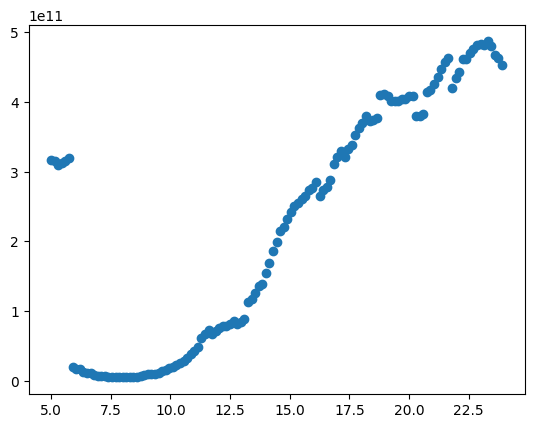

In [212]:
from matplotlib import pyplot as plt
import numpy as np
# evaluate predictions
predictions = [
    predict_generic_tf(
        coords = (-40,375),
        doy=98,
        time=time,
        year=2024,
        input_coords='az_alt',
        time_ref='ut',
        target_indices=geo_physical_features
    )
    for time in np.arange(5,24,0.15)
]

# convert to log scale for better visualization
plt.scatter(np.arange(5,24,0.15), predictions, label='Predictions', )
ax = plt.gca()
# ax.set_yscale('log') # Set the y-axis to a logarithmic scale
# plt.ylim(0, 1e12)


### Performance metric setup

In [196]:
from datetime import datetime
import numpy as np
### load data
def timestamp_to_decimal_hour(timestamp):
    utc_time = datetime.utcfromtimestamp(timestamp)
    return utc_time.hour + utc_time.minute / 60 + utc_time.second / 3600

test_date = np.datetime64('2024-04-07') # define the test date
test_xr = xr.open_dataset('/Users/mateo/Documents/dev/Haystack/AzimuthalScans/content/EclipseReport/mlh240407k.004.nc') # make sure to use the correct data product


### recorded data product processing
# Construct UT from UTC timestamp and attach to test dataset
dates = []
times = test_xr['timestamps'].data
ut = np.zeros(len(times))
for i in range(len(times)):
    temp = datetime.utcfromtimestamp(times[i])
    dates.append(temp)
    ut[i] = temp.hour + temp.minute / 60.0 + temp.second / 3600.0
# Convert the list of datetime objects to a pandas DatetimeIndex
pd_dates = pd.to_datetime(dates)
# Add the dates as a new coordinate in the xarray Dataset and set it as a dimension
test_xr = test_xr.assign_coords(dates=('timestamps', pd_dates))
test_xr = test_xr.swap_dims({'timestamps': 'dates'})
# Add UT hour variable to the dataset
ut = [timestamp_to_decimal_hour(ts) for ts in test_xr.timestamps.data]
test_xr['ut'] = (('dates',), ut)
test_xr['ut'].attrs = {
    "units": "hour of the day in decimal format",
    "long_name": "Universal Time Hour",
    "description": "Time in UTC expressed as a decimal hour."
}
# Add te variable to the dataset
test_xr['te'] = test_xr['tr'] * test_xr['ti']
test_xr['dte'] = test_xr['dtr'] * test_xr['dti']
# Add SLT variable to the dataset
slt = (test_xr.glon/15) + test_xr.ut # calculate correct SLT
test_xr['slt'] = (slt)
test_xr['slt'].attrs = {
    "units": "hours",
    "long_name": "Solar Local Time",
    "description": "Time in hours of the day, adjusted for longitude."
}
test_xr['az_normalized'] = (test_xr['az1'] + test_xr['az2']) / 2 # normalize az

### bin data by azimuth and generate modeled day with identical conditions
import warnings
from sklearn.exceptions import UndefinedMetricWarning
# Suppress warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

### target params
# target azimuth and width
target_az = -65
daz = 5
# Define bins for parameters
bins = {
    'alt': np.arange(150, 500, 25),  # Altitude bins (0-500 km, 50 km steps)
    'slt': np.arange(6, 19, .5) # time bins
}

# load and mask
target_xr = test_xr.copy(deep=True)
target_xr = target_xr.where(target_xr['dates'].dt.date == np.datetime64(test_date),drop=False) # target april 7th
az_mask = (target_xr['az1'] > (target_az - daz)) & (target_xr['az1'] < (target_az + daz))
target_xr = target_xr.where(az_mask, drop=True)
doy = pd.Timestamp(test_date).dayofyear


# ut_value = pd.Timestamp(target_xr.dates.data).hour + pd.Timestamp(target_xr.dates.data).minute / 60 + pd.Timestamp(target_xr.dates.data).second / 3600
# Adjust the shapes to match the number of bins (edges - 1)
n_alt_bins = len(bins['alt']) - 1
n_slt_bins = len(bins['slt']) - 1

### Calculating MAPE – Fized AZ

In [198]:
# --- MAPE over (alt_bin, slt_bin) ---

# Allocate outputs
mape = np.full((n_alt_bins, n_slt_bins), np.nan)      # final MAPE grid (percent)
Z = np.full((n_alt_bins, n_slt_bins), np.nan)         # mean observed (optional)
Z_modeled = np.full((n_alt_bins, n_slt_bins), np.nan) # mean modeled (optional)
lats = np.full((n_alt_bins, n_slt_bins), np.nan)
lons = np.full((n_alt_bins, n_slt_bins), np.nan)

EPS = 1e-9  # safeguard against division by (near) zero

for i, alt in enumerate(tqdm(bins['alt'][:-1])):
    alt_mask = (target_xr.gdalt >= bins['alt'][i]) & (target_xr.gdalt < bins['alt'][i+1])
    alt_masked_xr = target_xr.where(alt_mask, drop=False)

    for j, slt in enumerate(bins['slt'][:-1]):
        slt_mask = (alt_masked_xr.slt >= bins['slt'][j]) & (alt_masked_xr.slt < bins['slt'][j+1])

        # Observations in this bin
        target_lats = alt_masked_xr.gdlat.where(slt_mask, drop=True).data.flatten()
        target_lons = alt_masked_xr.glon.where(slt_mask, drop=True).data.flatten()
        y_true = alt_masked_xr['ne'].where(slt_mask, drop=True).data.flatten()

        if y_true.size == 0:
            # leave mape[i, j] as NaN
            continue

        # Build model inputs for exactly these samples
        n = y_true.size
        target_azs  = np.repeat(target_az, n)
        target_alts = np.repeat(alt,       n)
        target_slts = np.repeat(slt,       n)
        target_doys = np.repeat(doy,       n)

        y_pred = predict_generic_tf(
            coords=list(zip(target_azs.tolist(), target_alts.tolist())),
            doy=target_doys,
            time=target_slts,
            year=2024,
            input_coords='az_alt',
            time_ref='slt',
            # model_dict=bin_models,
            target_indices=geo_physical_features,

        )

        # Arrays + validity mask
        y_true = np.asarray(y_true).reshape(-1)
        y_pred = np.asarray(y_pred).reshape(-1)

        valid = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > EPS)
        if not np.any(valid):
            continue

        # MAPE (%) for this bin = mean(|(y_true - y_pred)/y_true|) * 100
        mape[i, j] = np.mean(np.abs((y_true[valid] - y_pred[valid]) / y_true[valid])) * 100.0

        # Optional diagnostics
        Z[i, j] = np.mean(y_true[valid])
        Z_modeled[i, j] = np.mean(y_pred[valid])
        lats[i, j] = np.nanmean(target_lats) if target_lats.size else np.nan
        lons[i, j] = np.nanmean(target_lons) if target_lons.size else np.nan

# Optional: wrap in xarray for labeled plotting
alt_midpoints = (bins['alt'][:-1] + bins['alt'][1:]) / 2
slt_midpoints = (bins['slt'][:-1] + bins['slt'][1:]) / 2
mape_da = xr.DataArray(
    mape,
    coords={'alt_bin_km': alt_midpoints, 'slt_bin_h': slt_midpoints},
    dims=('alt_bin_km', 'slt_bin_h'),
    name='mape_percent',
    attrs={'description': 'Mean Absolute Percentage Error (%) of Ne (model vs target)'}
)

100%|██████████| 13/13 [00:26<00:00,  2.02s/it]


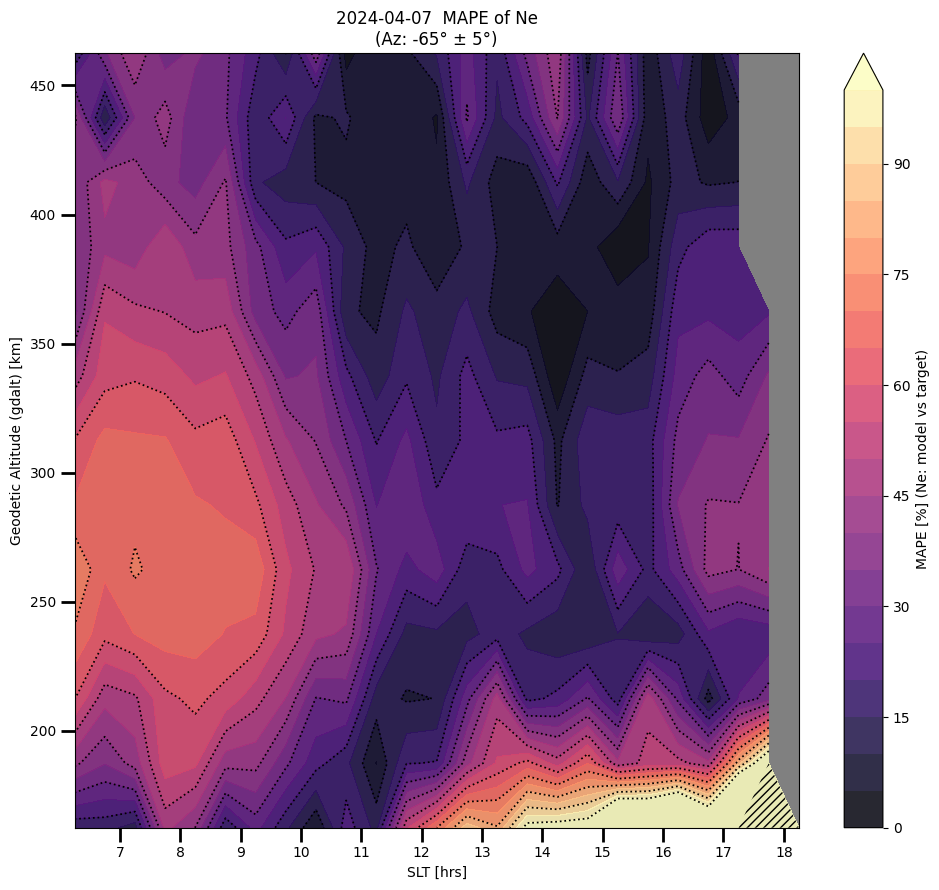

In [199]:
import matplotlib.pyplot as plt
import numpy as np

# Bin midpoints (same as before)
alt_midpoints = (bins['alt'][:-1] + bins['alt'][1:]) / 2
slt_midpoints = (bins['slt'][:-1] + bins['slt'][1:]) / 2
X, Y = np.meshgrid(slt_midpoints, alt_midpoints)

# MAPE grid (shape: len(alt_midpoints) x len(slt_midpoints))
mape_ma = np.ma.masked_invalid(mape)

# Levels: 0..100% for MAPE (non-negative). Use 'extend=max' to show >100% as overflow.
levels = np.linspace(0, 100, 21)

# Colormap
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color='grey')

fig, ax = plt.subplots(figsize=(10, 9))

# (1) Optional dotted isolines
ax.contour(
    X, Y, mape_ma,
    levels=levels[::2],
    colors='black',
    linewidths=1.25,
    linestyles='dotted'
)

# (2) Filled contours of MAPE
cs = ax.contourf(
    X, Y, mape_ma,
    levels=levels,
    cmap=cmap,
    extend='max',    # anything >100% uses the top color
    alpha=0.85
)

# (3) OPTIONAL: hatch bins with very high error (>= 100%)
mask_hatch = np.where(np.asarray(mape) >= 100.0, mape, np.nan)
if np.isfinite(mask_hatch).any():
    ax.contourf(
        X, Y, mask_hatch,
        levels=[100.0, np.nanmax(mask_hatch[np.isfinite(mask_hatch)])],
        colors='none',
        hatches=['////'],
        alpha=0
    )

# Colorbar
cbar = plt.colorbar(cs, ax=ax, label='MAPE [%] (Ne: model vs target)')

# Labels & styling
ax.set_xlabel('SLT [hrs]')
ax.set_ylabel('Geodetic Altitude (gdalt) [km]')
ax.set_facecolor('grey')

# Title
ax.set_title(f'{test_date}  MAPE of Ne\n(Az: {target_az}° ± {daz}°)')

# X ticks are numeric hours (not dates)
ax.set_xticks(np.arange(np.floor(slt_midpoints.min()),
                        np.ceil(slt_midpoints.max()) + 1, 1.0))
ax.tick_params(length=10, width=2)

# Limits
ax.set_xlim(slt_midpoints[0], slt_midpoints[-1])
ax.set_ylim(alt_midpoints[0], alt_midpoints[-1])

plt.tight_layout()
plt.show()

### Calculating MSE – Fixed AZ

In [200]:
# --- MSE over (alt_bin, slt_bin) ---

import numpy as np
from tqdm import tqdm

# Adjust the shapes to match the number of bins (edges - 1)
n_alt_bins = len(bins['alt']) - 1
n_slt_bins = len(bins['slt']) - 1

# Allocate outputs
mse = np.full((n_alt_bins, n_slt_bins), np.nan)  # final MSE grid
# (optional: keep these if you still want to look at means)
Z = np.full((n_alt_bins, n_slt_bins), np.nan)        # mean target
Z_modeled = np.full((n_alt_bins, n_slt_bins), np.nan)  # mean modeled
lats = np.full((n_alt_bins, n_slt_bins), np.nan)
lons = np.full((n_alt_bins, n_slt_bins), np.nan)

for i, alt in enumerate(tqdm(bins['alt'][:-1])):
    alt_mask = (target_xr.gdalt >= bins['alt'][i]) & (target_xr.gdalt < bins['alt'][i+1])
    alt_masked_xr = target_xr.where(alt_mask, drop=False)

    for j, slt in enumerate(bins['slt'][:-1]):
        slt_mask = (alt_masked_xr.slt >= bins['slt'][j]) & (alt_masked_xr.slt < bins['slt'][j+1])

        # Gather observed values for this (alt, slt) bin
        target_lats = alt_masked_xr.gdlat.where(slt_mask, drop=True).data.flatten()
        target_lons = alt_masked_xr.glon.where(slt_mask, drop=True).data.flatten()
        target_values = alt_masked_xr['ne'].where(slt_mask, drop=True).data.flatten()

        if target_values.size == 0:
            # leave mse[i, j] as NaN
            continue

        # Build inputs for the model for exactly these samples
        target_azs  = np.repeat(target_az, target_lats.size)
        target_alts = np.repeat(alt,       target_lats.size)
        target_slts = np.repeat(slt,       target_lats.size)
        target_doys = np.repeat(doy,       target_lats.size)

        modeled_values = predict_generic_tf(
            coords=list(zip(target_azs.tolist(), target_alts.tolist())),
            doy=target_doys,
            time=target_slts,
            year=2024,
            input_coords='az_alt',
            time_ref='slt',
            # model_dict=bin_models,
            target_indices=geo_physical_features,
        )

        # Ensure 1-D numpy arrays and align valid pairs
        modeled_values = np.asarray(modeled_values).reshape(-1)
        target_values = np.asarray(target_values).reshape(-1)

        # Some models may return NaNs; compute MSE over valid pairs only
        valid = np.isfinite(target_values) & np.isfinite(modelled_values := modeled_values)
        if not np.any(valid):
            continue

        diffsq = (target_values[valid] - modelled_values[valid])**2
        mse[i, j] = np.mean(diffsq)

        # (optional diagnostics)
        Z[i, j] = np.nanmean(target_values[valid]) if np.any(valid) else np.nan
        Z_modeled[i, j] = np.nanmean(modelled_values[valid]) if np.any(valid) else np.nan
        lats[i, j] = np.nanmean(target_lats) if target_lats.size else np.nan
        lons[i, j] = np.nanmean(target_lons) if target_lons.size else np.nan

# If you want an xarray wrapper with bin midpoints:
alt_midpoints = (bins['alt'][:-1] + bins['alt'][1:]) / 2
slt_midpoints = (bins['slt'][:-1] + bins['slt'][1:]) / 2
mse_da = xr.DataArray(
    mse,
    coords={'alt_bin_km': alt_midpoints, 'slt_bin_h': slt_midpoints},
    dims=('alt_bin_km', 'slt_bin_h'),
    name='mse'
)

100%|██████████| 13/13 [00:26<00:00,  2.07s/it]


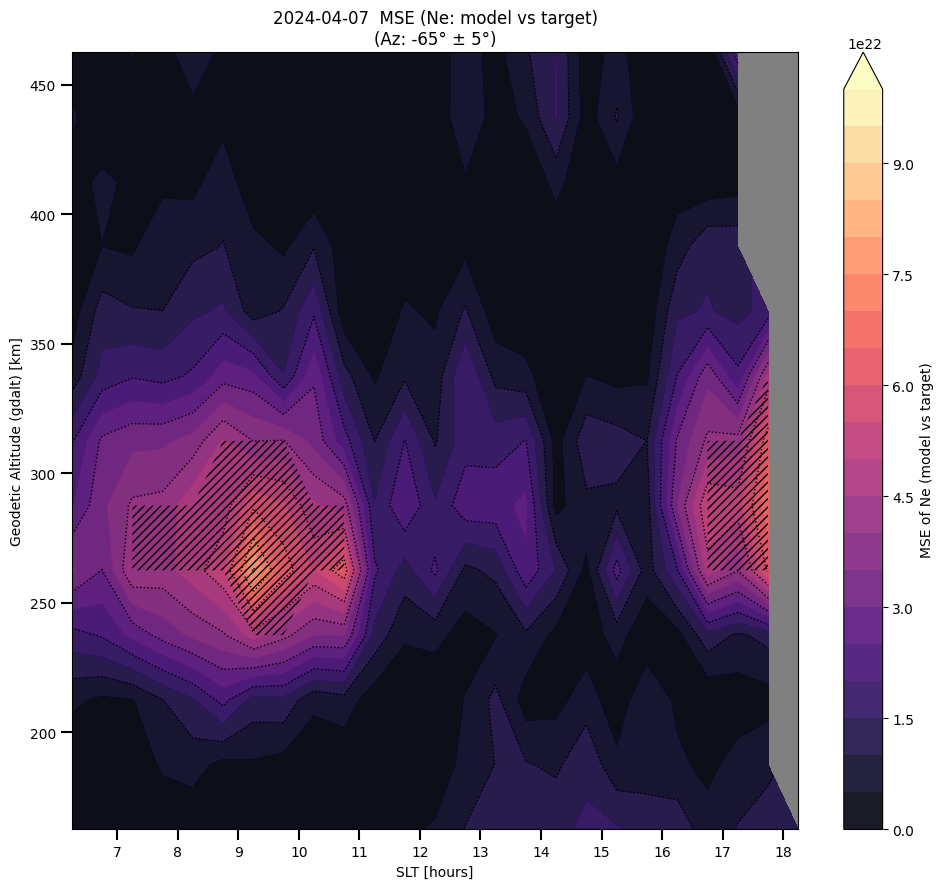

In [201]:
import matplotlib.pyplot as plt
import numpy as np

# --- Prep grid from your bin edges ---
alt_midpoints = (bins['alt'][:-1] + bins['alt'][1:]) / 2
slt_midpoints = (bins['slt'][:-1] + bins['slt'][1:]) / 2
X, Y = np.meshgrid(slt_midpoints, alt_midpoints)

# Mask NaNs to render them as grey
mse_ma = np.ma.masked_invalid(mse)

# Choose levels robustly (avoid outliers dominating the color range)
finite_vals = mse_ma.compressed()
if finite_vals.size:
    vmin = 0.0
    vmax = np.quantile(finite_vals, 0.98)  # 98th percentile cap
    if vmax <= vmin:
        vmax = float(np.max(finite_vals))
else:
    vmin, vmax = 0.0, 1.0

levels = np.linspace(vmin, 1e23, 21)

# Colormap (sequential works best for error magnitude)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color='grey')

fig, ax = plt.subplots(figsize=(10, 9))

# (1) Optional dotted contour lines (iso-MSE)
cs2 = ax.contour(
    X, Y, mse_ma,
    levels=levels[::2],
    colors='black',
    linewidths=1.0,
    linestyles='dotted'
)

# (2) Filled contours of MSE
cs = ax.contourf(
    X, Y, mse_ma,
    levels=levels,
    cmap=cmap,
    extend='max',
    alpha=0.9
)

# (3) OPTIONAL: hatch top-10% highest MSE areas
if finite_vals.size:
    hi_thresh = np.quantile(finite_vals, 0.90)
    mask_hatch = np.where(mse >= hi_thresh, mse, np.nan)
    if np.isfinite(mask_hatch).any():
        ax.contourf(
            X, Y, mask_hatch,
            levels=[hi_thresh, np.nanmax(mask_hatch[np.isfinite(mask_hatch)])],
            colors='none',
            hatches=['////'],
            alpha=0
        )

# Colorbar
cbar = plt.colorbar(cs, ax=ax, label='MSE of Ne (model vs target)')

# Labels & styling
ax.set_xlabel('SLT [hours]')
ax.set_ylabel('Geodetic Altitude (gdalt) [km]')
ax.set_facecolor('grey')

# Title
ax.set_title(f'{test_date}  MSE (Ne: model vs target)\n(Az: {target_az}° ± {daz}°)')

# X ticks every hour (since SLT is numeric hours)
xtick_start = np.floor(slt_midpoints.min())
xtick_end = np.ceil(slt_midpoints.max())
ax.set_xticks(np.arange(xtick_start, xtick_end + 0.5, 1.0))
ax.tick_params(length=8, width=1.5)

# Limits
ax.set_xlim(slt_midpoints[0], slt_midpoints[-1])
ax.set_ylim(alt_midpoints[0], alt_midpoints[-1])

plt.tight_layout()
plt.show()

### Calculating MAPE – Fixed ALT

In [202]:
# === MAPE over (az_bin, slt_bin) at fixed altitude 350 ± 25 km ===
from tqdm import tqdm
import numpy as np

# Fixed altitude window
ALT_CENTER = 225.0
ALT_HALF_WIDTH = 25.0
alt_lo, alt_hi = ALT_CENTER - ALT_HALF_WIDTH, ALT_CENTER + ALT_HALF_WIDTH

# --- Bins ---
# Y-axis: azimuth bins [-140, -36] with width 6.5°
az_edges = np.arange(-140.0, -36.0 + 6.5, 6.5)  # edges inclusive on the right by padding
az_midpoints = (az_edges[:-1] + az_edges[1:]) / 2

# X-axis: SLT bins as before
slt_edges = np.arange(6, 19, 0.5)
slt_midpoints = (slt_edges[:-1] + slt_edges[1:]) / 2

n_az_bins = len(az_edges) - 1
n_slt_bins = len(slt_edges) - 1

# Prepare arrays
mape = np.full((n_az_bins, n_slt_bins), np.nan)      # final metric
Z_true = np.full((n_az_bins, n_slt_bins), np.nan)    # optional: mean observed
Z_pred = np.full((n_az_bins, n_slt_bins), np.nan)    # optional: mean modeled

# Restrict to date first (already done) and then to fixed altitude window
target_xr = test_xr.copy(deep=True)
target_xr = target_xr.where(target_xr['dates'].dt.date == np.datetime64(test_date), drop=False)

alt_mask = (target_xr.gdalt >= alt_lo) & (target_xr.gdalt < alt_hi)
alt_xr = target_xr.where(alt_mask, drop=False)

# We'll bin by az using the normalized azimuth
if 'az_normalized' not in alt_xr:
    alt_xr = alt_xr.assign(az_normalized=(('dates',), (alt_xr['az1'] + alt_xr['az2']) / 2.0))

doy = pd.Timestamp(test_date).dayofyear
EPS = 1e-9  # to avoid division by ~zero in MAPE

for i, az_left in enumerate(tqdm(az_edges[:-1], desc="Az bins")):
    az_right = az_edges[i + 1]
    az_center = az_midpoints[i]

    az_mask = (alt_xr.az_normalized >= az_left) & (alt_xr.az_normalized < az_right)
    az_xr = alt_xr.where(az_mask, drop=False)

    for j, slt_left in enumerate(slt_edges[:-1]):
        slt_right = slt_edges[j + 1]
        slt_center = slt_left  # match your prior convention (left-edge); use slt_midpoints[j] if you prefer centers

        slt_mask = (az_xr.slt >= slt_left) & (az_xr.slt < slt_right)

        # Observed Ne for this bin
        y_true = az_xr['ne'].where(slt_mask, drop=True).data.flatten()
        if y_true.size == 0:
            continue

        # Build model inputs for exactly these samples (evaluate at bin centers)
        n = y_true.size
        azs = np.repeat(az_center, n)
        alts = np.repeat(ALT_CENTER, n)
        slts = np.repeat(slt_center, n)
        doys = np.repeat(doy, n)

        y_pred = predict_generic_tf(
            coords=list(zip(azs.tolist(), alts.tolist())),
            doy=doys,
            time=slts,
            year=2024,
            input_coords='az_alt',
            time_ref='slt',
            # model_dict=bin_models,
            target_indices=geo_physical_features,
        )

        y_true = np.asarray(y_true).reshape(-1)
        y_pred = np.asarray(y_pred).reshape(-1)

        # Valid pairs: finite and |y_true| > EPS
        valid = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > EPS)
        if not np.any(valid):
            continue

        # Mean Absolute Percentage Error (%)
        mape[i, j] = np.mean(np.abs((y_true[valid] - y_pred[valid]) / y_true[valid])) * 100.0

        # Optional diagnostics
        Z_true[i, j] = np.mean(y_true[valid])
        Z_pred[i, j] = np.mean(y_pred[valid])

# Optional: wrap as an xarray for labeled plotting
mape_da = xr.DataArray(
    data=mape,
    coords={'az_bin_deg': az_midpoints, 'slt_bin_h': slt_midpoints},
    dims=('az_bin_deg', 'slt_bin_h'),
    name='MAPE_ne_percent',
    attrs={'description': 'MAPE (%) between observed Ne and modeled Ne at 350±25 km'}
)

Az bins:   0%|          | 0/16 [00:00<?, ?it/s]

Az bins: 100%|██████████| 16/16 [00:33<00:00,  2.07s/it]


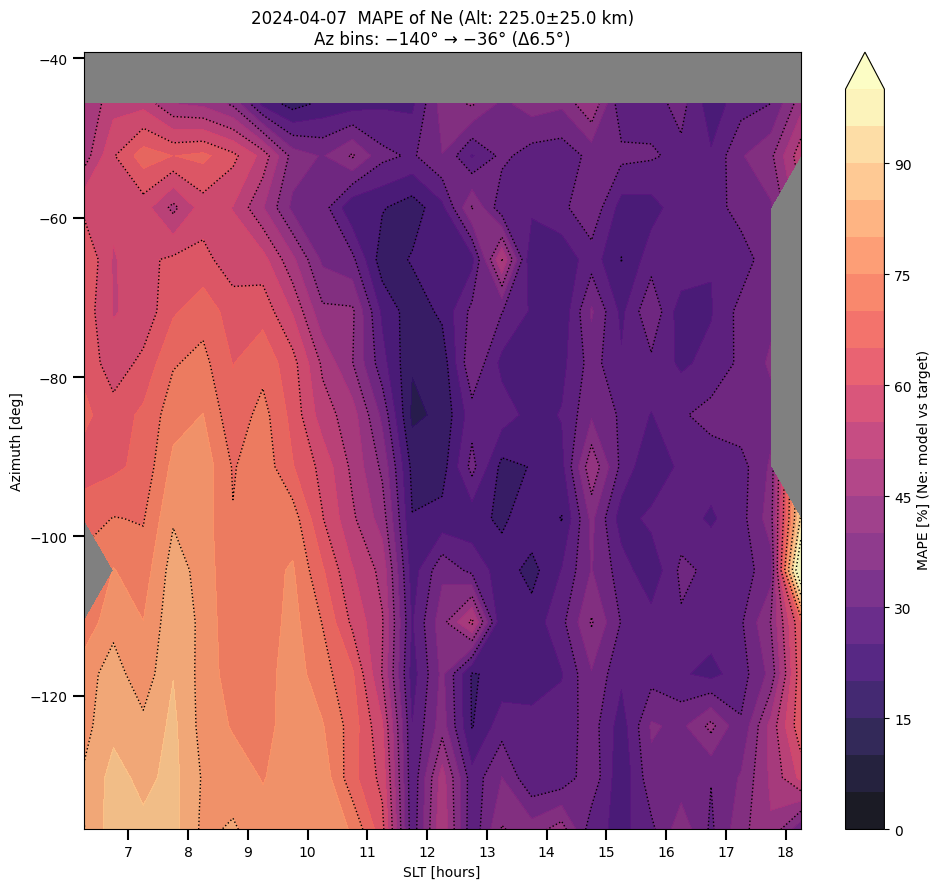

In [203]:
import matplotlib.pyplot as plt
import numpy as np

# --- Axes (must match how you computed `mape`) ---
az_edges = np.arange(-140.0, -36.0 + 6.5, 6.5)
az_midpoints = (az_edges[:-1] + az_edges[1:]) / 2
slt_edges = np.arange(6, 19, 0.5)
slt_midpoints = (slt_edges[:-1] + slt_edges[1:]) / 2

# Grid
X, Y = np.meshgrid(slt_midpoints, az_midpoints)

# Mask NaNs for clean rendering
mape_ma = np.ma.masked_invalid(mape)

# Robust level range for MAPE (%)
finite_vals = mape_ma.compressed()
if finite_vals.size:
    vmin = 0.0
    vmax = np.quantile(finite_vals, 0.98)  # cap outliers
    if vmax <= vmin:
        vmax = float(np.max(finite_vals))
else:
    vmin, vmax = 0.0, 1.0

levels = np.linspace(0, 100, 21)

# Sequential colormap for nonnegative error
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color='grey')

fig, ax = plt.subplots(figsize=(10, 9))

# (1) Optional dotted isolines
ax.contour(
    X, Y, mape_ma,
    levels=levels[::2],
    colors='black',
    linewidths=1.0,
    linestyles='dotted'
)

# (2) Filled contours of MAPE
cs = ax.contourf(
    X, Y, mape_ma,
    levels=levels,
    cmap=cmap,
    extend='max',
    alpha=0.9
)

# (3) OPTIONAL hatching for high-error areas (≥100% MAPE)
if finite_vals.size:
    hi_thresh = 100.0
    mask_hatch = np.where(mape >= hi_thresh, mape, np.nan)
    if np.isfinite(mask_hatch).any():
        ax.contourf(
            X, Y, mask_hatch,
            levels=[hi_thresh, np.nanmax(mask_hatch[np.isfinite(mask_hatch)])],
            colors='none',
            hatches=['////'],
            alpha=0
        )

# Colorbar
cbar = plt.colorbar(cs, ax=ax, label='MAPE [%] (Ne: model vs target)')

# Labels & styling
ax.set_xlabel('SLT [hours]')
ax.set_ylabel('Azimuth [deg]')
ax.set_facecolor('grey')

# Title (fixed altitude)
ax.set_title(f'{test_date}  MAPE of Ne (Alt: {ALT_CENTER}±{ALT_HALF_WIDTH} km)\n'
             f'Az bins: −140° → −36° (Δ6.5°)')

# Ticks & limits
ax.set_xticks(np.arange(np.floor(slt_midpoints.min()), np.ceil(slt_midpoints.max()) + 1, 1.0))
ax.set_xlim(slt_midpoints[0], slt_midpoints[-1])
ax.set_ylim(az_midpoints[0], az_midpoints[-1])
ax.tick_params(length=8, width=1.5)

plt.tight_layout()
plt.show()

### Calculating MSE – Fixed Alt

In [204]:
# === MSE over (az_bin, slt_bin) at fixed altitude 350 ± 25 km ===
from tqdm import tqdm
import numpy as np

ALT_CENTER = 225.0
ALT_HALF_WIDTH = 25.0
alt_lo, alt_hi = ALT_CENTER - ALT_HALF_WIDTH, ALT_CENTER + ALT_HALF_WIDTH

# Azimuth bins (Y axis): previously defined range/width
az_edges = np.arange(-140.0, -36.0 + 6.5, 6.5)
az_midpoints = (az_edges[:-1] + az_edges[1:]) / 2
n_az_bins = len(az_edges) - 1

# SLT bins (X axis): reuse your existing SLT edges
slt_edges = np.arange(6, 19, 0.5)  # or: bins['slt']
slt_midpoints = (slt_edges[:-1] + slt_edges[1:]) / 2
n_slt_bins = len(slt_edges) - 1

# Outputs
mse = np.full((n_az_bins, n_slt_bins), np.nan)      # final MSE grid
Z_true = np.full((n_az_bins, n_slt_bins), np.nan)   # optional diagnostics
Z_pred = np.full((n_az_bins, n_slt_bins), np.nan)   # optional diagnostics

# Restrict to date and fixed altitude window
target_xr = test_xr.copy(deep=True)
target_xr = target_xr.where(target_xr['dates'].dt.date == np.datetime64(test_date), drop=False)
alt_mask = (target_xr.gdalt >= alt_lo) & (target_xr.gdalt < alt_hi)
alt_xr = target_xr.where(alt_mask, drop=False)

# Ensure normalized azimuth exists
if 'az_normalized' not in alt_xr:
    alt_xr = alt_xr.assign(az_normalized=(('dates',), (alt_xr['az1'] + alt_xr['az2']) / 2.0))

doy = pd.Timestamp(test_date).dayofyear

for i, az_left in enumerate(tqdm(az_edges[:-1], desc="Az bins")):
    az_right = az_edges[i + 1]
    az_center = az_midpoints[i]

    az_mask = (alt_xr.az_normalized >= az_left) & (alt_xr.az_normalized < az_right)
    az_xr = alt_xr.where(az_mask, drop=False)

    for j, slt_left in enumerate(slt_edges[:-1]):
        slt_right = slt_edges[j + 1]
        slt_center = slt_left   # use left-edge for time; switch to slt_midpoints[j] if you prefer centers

        # Observed Ne samples for this bin
        y_true = az_xr['ne'].where((az_xr.slt >= slt_left) & (az_xr.slt < slt_right), drop=True).data.flatten()
        if y_true.size == 0:
            continue

        # Predict for exactly these samples at bin centers (az_center, ALT_CENTER, slt_center)
        n = y_true.size
        azs  = np.repeat(az_center, n)
        alts = np.repeat(ALT_CENTER, n)
        slts = np.repeat(slt_center, n)
        doys = np.repeat(doy, n)

        y_pred = predict_generic_tf(
            coords=list(zip(azs.tolist(), alts.tolist())),
            doy=doys,
            time=slts,
            year=2024,
            input_coords='az_alt',
            time_ref='slt',
            # model_dict=bin_models,
            target_indices=geo_physical_features,
        )

        y_true = np.asarray(y_true).reshape(-1)
        y_pred = np.asarray(y_pred).reshape(-1)

        valid = np.isfinite(y_true) & np.isfinite(y_pred)
        if not np.any(valid):
            continue

        # Mean Squared Error for the bin
        diffsq = (y_true[valid] - y_pred[valid])**2
        mse[i, j] = np.mean(diffsq)

        # Optional diagnostics
        Z_true[i, j] = np.mean(y_true[valid])
        Z_pred[i, j] = np.mean(y_pred[valid])

# Optional: wrap as xarray for labeled plotting
mse_da = xr.DataArray(
    data=mse,
    coords={'az_bin_deg': az_midpoints, 'slt_bin_h': slt_midpoints},
    dims=('az_bin_deg', 'slt_bin_h'),
    name='mse',
    attrs={'description': 'MSE of Ne (model vs target) at 350±25 km'}
)

Az bins: 100%|██████████| 16/16 [00:33<00:00,  2.10s/it]


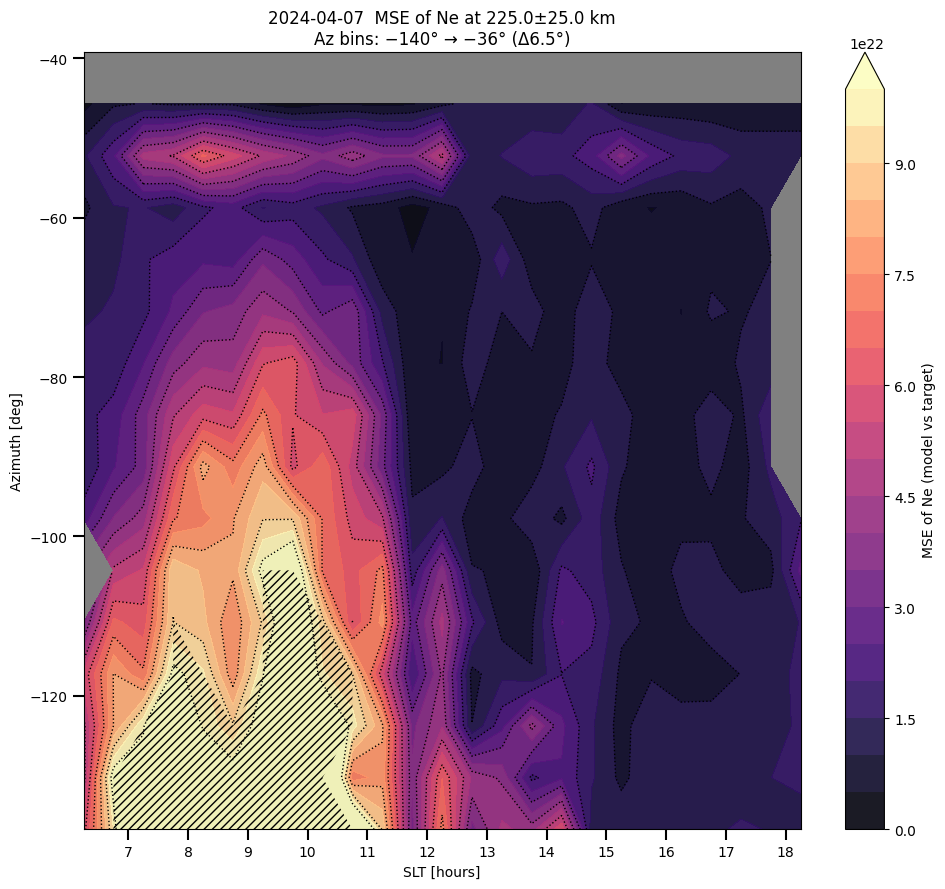

In [205]:
import matplotlib.pyplot as plt
import numpy as np

# --- Axes must match how you computed `mse` ---
az_edges = np.arange(-140.0, -36.0 + 6.5, 6.5)
az_midpoints = (az_edges[:-1] + az_edges[1:]) / 2
slt_edges = np.arange(6, 19, 0.5)  # same as in your binning
slt_midpoints = (slt_edges[:-1] + slt_edges[1:]) / 2

# Grid
X, Y = np.meshgrid(slt_midpoints, az_midpoints)

# Mask NaNs to render as grey
mse_ma = np.ma.masked_invalid(mse)

# Robust levels (avoid outliers dominating)
finite_vals = mse_ma.compressed()
if finite_vals.size:
    vmin = 0.0
    vmax = np.quantile(finite_vals, 0.98)
    if vmax <= vmin:
        vmax = float(np.max(finite_vals))
else:
    vmin, vmax = 0.0, 1.0

levels = np.linspace(vmin, 1e23, 21)

# Sequential colormap (errors are non-negative)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad(color='grey')

fig, ax = plt.subplots(figsize=(10, 9))

# (1) Optional dotted iso-MSE lines
ax.contour(
    X, Y, mse_ma,
    levels=levels[::2],
    colors='black',
    linewidths=1.0,
    linestyles='dotted'
)

# (2) Filled contours of MSE
cs = ax.contourf(
    X, Y, mse_ma,
    levels=levels,
    cmap=cmap,
    extend='max',
    alpha=0.9
)

# (3) OPTIONAL: hatch top-10% highest MSE areas
if finite_vals.size:
    hi_thresh = np.quantile(finite_vals, 0.90)
    mask_hatch = np.where(mse >= hi_thresh, mse, np.nan)
    if np.isfinite(mask_hatch).any():
        ax.contourf(
            X, Y, mask_hatch,
            levels=[hi_thresh, np.nanmax(mask_hatch[np.isfinite(mask_hatch)])],
            colors='none',
            hatches=['////'],
            alpha=0
        )

# Colorbar
plt.colorbar(cs, ax=ax, label='MSE of Ne (model vs target)')

# Labels & styling
ax.set_xlabel('SLT [hours]')
ax.set_ylabel('Azimuth [deg]')
ax.set_facecolor('grey')

# Title
ax.set_title(
    f'{test_date}  MSE of Ne at {ALT_CENTER}±{ALT_HALF_WIDTH} km\n'
    'Az bins: −140° → −36° (Δ6.5°)'
)

# Ticks & limits
ax.set_xticks(np.arange(np.floor(slt_midpoints.min()),
                        np.ceil(slt_midpoints.max()) + 1, 1.0))
ax.set_xlim(slt_midpoints[0], slt_midpoints[-1])
ax.set_ylim(az_midpoints[0], az_midpoints[-1])
ax.tick_params(length=8, width=1.5)

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge

# — Assumptions —
# target_df, az_bin_edges, alt_bin_edges, target, target_az, bins,
# predict_ne, doy (for your training split), and the following are defined:
#   april_6th_xr, april_7th_xr, april_9th_xr, april_10th_xr
#   Z_april6th, Z_april7th, Z_april9th, Z_april10th

# Prepare dicts of test days
daily_xr = {
    "Apr 6":  april_6th_xr,
    "Apr 7":  april_7th_xr,
    "Apr 9":  april_9th_xr,
    "Apr 10": april_10th_xr
}
daily_Z = {
    "Apr 6":  Z_april6th,
    "Apr 7":  Z_april7th,
    "Apr 9":  Z_april9th,
    "Apr 10": Z_april10th
}

# Your two features now fixed:
fixed_indices = ['fism2_48hr_prior', 'ap_7hr_prior']

best_score = np.inf
best_params = None

# Precompute dimensions
n_alt = len(bins['alt']) - 1
n_slt = len(bins['slt']) - 1
valid_slt = ((bins['slt'][:-1] + bins['slt'][1:]) / 2.0 >= 5) & \
            ((bins['slt'][:-1] + bins['slt'][1:]) / 2.0 <= 19.5)

# Grid‐search over dAz and dAlt
for dAz in np.arange(1, 11, 1):             # example: 1° to 10°
    for dAlt in [22.0, 23.0, 24.32, 25.0, 26.0]:  # include your sensitive values
        # Re‐bin target_df with this (dAz, dAlt)
        az_edges = np.arange(set_az_domain[0], set_az_domain[1] + dAz, dAz)
        target_df['az_bin'] = pd.cut(target_df['az'], bins=az_edges,
                                     labels=False, right=False)
        alt_edges = np.arange(set_alt_domain[0], set_alt_domain[1] + dAlt, dAlt)
        target_df['alt_bin'] = pd.cut(target_df['alt'], bins=alt_edges,
                                      labels=False, right=False)

        # Train bin models (same as before, but only 2 features + time)
        current_bin_models = {}
        features = ['doy','slt'] + fixed_indices
        for (azb, altb), grp in target_df.groupby(['az_bin','alt_bin']):
            if len(grp) < 6:
                continue
            X = grp[features].values
            y = grp[target].values
            Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.33, random_state=42)
            scaler = StandardScaler().fit(Xtr)
            Xtr_s = scaler.transform(Xtr)
            poly = PolynomialFeatures(degree=4, include_bias=False)
            Xtr_p = poly.fit_transform(Xtr_s)
            mdl = Ridge(alpha=1).fit(Xtr_p, ytr)
            azr = (az_edges[int(azb)], az_edges[int(azb)+1])
            altr = (alt_edges[int(altb)], alt_edges[int(altb)+1])
            current_bin_models[(azb,altb)] = {
                'model': mdl, 'scaler': scaler, 'poly': poly,
                'az_range': azr, 'alt_range': altr
            }

        # swap in our bin_models
        global bin_models
        old = bin_models
        bin_models = current_bin_models

        # Evaluate on each day and collect residuals
        daily_res = []
        for day, Z_true in daily_Z.items():
            # predict Z_modeled for this day
            Z_mod = np.full((n_alt, n_slt), np.nan)
            xr_day = daily_xr[day]
            # loop bins
            for i in range(n_alt):
                for j in range(n_slt):
                    # build masks for this alt/sl...
                    am = (xr_day.gdalt >= bins['alt'][i]) & \
                         (xr_day.gdalt <  bins['alt'][i+1])
                    sm = (xr_day.slt   >= bins['slt'][j]) & \
                         (xr_day.slt   <  bins['slt'][j+1])
                    sub = xr_day.where(am & sm, drop=True)
                    if sub.ne.count()==0:
                        continue
                    count = int(sub.ne.count())
                    # prepare query arrays
                    azq  = np.repeat(target_az, count)
                    altq = np.repeat((bins['alt'][i]+bins['alt'][i+1])/2, count)
                    sltq = np.repeat((bins['slt'][j]+bins['slt'][j+1])/2, count)
                    doyq = np.repeat(doy, count)
                    preds = predict_ne(azq, altq, doyq, sltq, year=2024,
                                       target_indices=fixed_indices)
                    Z_mod[i,j] = preds.mean()
            # compute residual on valid SLT slice
            Zv = Z_true[:,valid_slt]
            Zv = Z_mod[:,valid_slt]
            daily_res.append(np.nanmean(np.abs((Zv-Zv)/Zv)*100))

        # restore original
        bin_models = old

        # average over days, record
        avg = np.mean(daily_res)
        combination_results[(dAz,dAlt)] = avg

        # plot
        plt.figure(figsize=(5,3))
        plt.bar(list(daily_Z.keys()), daily_res, color='C0')
        plt.axhline(avg, color='r', linestyle='--',
                    label=f'Avg {avg:.1f}%')
        plt.title(f"dAz={dAz}, dAlt={dAlt}")
        plt.ylabel("Mean residual [%]")
        plt.legend()
        plt.tight_layout()
        plt.show()

        if avg < best_score:
            best_score = avg
            best_combination = (dAz, dAlt)

print("Best (dAz, dAlt):", best_combination,
      "→ Mean residual:", best_score)
